# Baseline de clasificación de cultivos — Random Forest, XGBoost y LightGBM

Este cuaderno responde una pregunta concreta: **¿qué tan lejos llega un modelo tabular sencillo para clasificar cultivos a partir de imágenes satelitales?** Se entrenan tres modelos de árboles (Random Forest, XGBoost y LightGBM) sobre un vector de características que combina el embedding AlphaEarth de 64 dimensiones, los 17 índices espectrales × 9 estadísticos, FFT del NDVI, atributos fenológicos, ERA5 mensual y SRTM. El resultado sirve de **punto de referencia**: cualquier modelo más complejo en fases posteriores tendrá que superar estas cifras para justificar su coste.

El cuaderno aborda cinco preguntas a lo largo del análisis:

1. **¿Por qué elegir Random Forest, XGBoost y LightGBM** como modelos de referencia?
2. **¿Qué características explican las predicciones**, según la importancia nativa (Gini, gain) y SHAP?
3. **¿Cuánto del poder predictivo proviene del embedding AlphaEarth** frente a índices espectrales, terreno y clima?
4. **¿El baseline sub o sobreajusta?** Diagnóstico con curvas de aprendizaje y validación.
5. **¿AlphaEarth aporta valor frente a las bandas Sentinel-2 crudas** o frente al vector combinado de features espectro-temporales?

Y cierra con una sexta pregunta de medición:

6. **¿El F1-macro modesto sobre 18 clases refleja falta de señal, o castigo por confundir cultivos hermanos?** La sección 8 reentrena el mismo modelo sobre los 6 grupos HCAT Level-1 para separar ambos efectos.

## Requisitos para ejecución end-to-end

- Subset PASTIS-R a nivel parcela descomprimido en `data/test_fixtures/feature_selection_parcels_subset.parquet`.
- Geoparquet de parcelas en `data/processed/pastis_parcels_full.geoparquet`.
- Para la sección 8 (18 clases vs 6 grupos HCAT): los embeddings AlphaEarth anuales `data/cache/gee/alphaearth_parcels_parcels_2018_85951.parquet` y `alphaearth_parcels_pastis_parcels_2019_85951.parquet` (descargables vía `dvc pull`).
- Para la sección 7 (AlphaEarth vs S2 crudo): los parquets `alphaearth_pastis_parcels_2019_85951_enriched.parquet` y `s2_raw_parcels_2019_85951.parquet` en `data/cache/`; si faltan, esa sección se omite con un aviso explícito.
- Dependencias instaladas vía `poetry install --with ml,geo`.


In [1]:
FEATURES_PATH = "data/test_fixtures/feature_selection_parcels_subset.parquet"
PARCELS_GEOPARQUET = "data/processed/pastis_parcels_full.geoparquet"
FIGURES_SUBDIR = "us-023-preview/04_baseline"
REPORTS_SUBDIR = "baseline/04_baseline"
K_FOLDS = 5
BUFFER_KM = 1.0
RANDOM_STATE = 42
SHAP_SAMPLE_SIZE = 3000
TOP_FEATURES_DISPLAY = 20
F1_THRESHOLD = 0.60
LEARNING_CURVE_MAX_SAMPLES = 12000
# Seccion 11 - comparativa AlphaEarth vs S2 crudo vs vector combinado.
SCENARIO_ALPHAEARTH_PATH = "data/cache/gee/alphaearth_pastis_parcels_2019_85951_enriched.parquet"
SCENARIO_S2_RAW_PATH = "data/cache/pastis/s2_raw_parcels_2019_85951.parquet"
SCENARIO_COMBINED_PATH = "data/test_fixtures/feature_selection_parcels_subset.parquet"
COMPARISON_MAX_SAMPLES = 0  # 0 = inner join completo
COMPARISON_K_FOLDS = 5
# MLflow tracking — experimento global del Avance 3 baseline.
MLFLOW_EXPERIMENT = "baseline-04-tabular"


In [2]:
from __future__ import annotations

import os
import sys
from pathlib import Path

# Bootstrap: localizar el repo root buscando pyproject.toml
_HERE = Path.cwd().resolve()
for _candidate in (_HERE, *_HERE.parents):
    if (_candidate / "pyproject.toml").is_file():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break

from ml.utils.notebook_bootstrap import setup_notebook
from IPython.display import Markdown, display

env = setup_notebook(
    figures_subdir=FIGURES_SUBDIR,
    reports_subdir=REPORTS_SUBDIR,
)
display(Markdown(env.summary_markdown()))

# Chdir al repo root para que las rutas relativas de la celda `parameters`
# (FEATURES_PATH = "data/...", etc.) resuelvan igual sin importar desde donde
# se haya lanzado el kernel (VS Code abre con cwd = carpeta del notebook).
# Esto preserva el contrato papermill (parametros como strings relativas) y
# elimina FileNotFoundError causado por cwd != repo root.
os.chdir(env.repo)
display(Markdown(f"**cwd anclado al repo root**: `{env.repo}`"))


| Recurso | Estado |
|---|---|
| Repo root | `/mnt/data/agro_sat_copilot` |
| Figures dir | `paper/figures/us-023-preview/04_baseline` |
| Reports dir | `reports/baseline/04_baseline` |
| Gemini API key | presente |
| Earth Engine | configurado |
| GEE project | `agrosat-copilot` |

**cwd anclado al repo root**: `/mnt/data/agro_sat_copilot`

### Trazabilidad MLflow

Cada modelo entrenado abre un *run* en el experimento `baseline-04-tabular` con los tags `code_version` (SHA git) y `data_version` (hash DVC del parquet de features). Las métricas (F1-macro, F1-weighted, mIoU, accuracy, kappa) y los hiperparámetros quedan registrados para reabrir y reproducir cualquier corrida desde la UI MLflow en `http://localhost:5010`.

In [3]:
from ml.utils.mlflow_utils import (
    resolve_tracking_uri,
    track_experiment,
    server_is_reachable,
)

# Resolucion robusta del tracking URI: si MLFLOW_TRACKING_URI esta en
# `.env.local` pero el server no responde (Docker apagado, contenedor
# detenido), caemos a `file:./mlruns` para no detener el notebook.
_candidate_uri = resolve_tracking_uri(None, probe_server=False)
if _candidate_uri.startswith(('http://', 'https://')) and not server_is_reachable(_candidate_uri):
    mlflow_uri = 'file:./mlruns'
    display(Markdown(
        f'> Servidor MLflow `{_candidate_uri}` no responde. '
        'Caigo a tracking local `file:./mlruns`. '
        'Para registrar en el server, ejecuta `docker compose up -d mlflow` '
        'antes de re-ejecutar las celdas MLflow.'
    ))
else:
    mlflow_uri = _candidate_uri
display(Markdown(
    f'**MLflow tracking URI**: `{mlflow_uri}` · '
    f'**Experimento**: `{MLFLOW_EXPERIMENT}`'
))
MLFLOW_RUN_IDS: dict[str, str] = {}


> Servidor MLflow `https://agrosat-mlflow-dev-gox5zzl7wa-uc.a.run.app` no responde. Caigo a tracking local `file:./mlruns`. Para registrar en el server, ejecuta `docker compose up -d mlflow` antes de re-ejecutar las celdas MLflow.

**MLflow tracking URI**: `file:./mlruns` · **Experimento**: `baseline-04-tabular`

## 1. Carga del conjunto de datos

El conjunto de entrada es un subset de PASTIS-R a nivel de parcela: 85 951 parcelas agrícolas con 187 características espectro-temporales cada una. La etiqueta es el tipo de cultivo (PASTIS-R define 18 clases activas tras descartar las de fondo). El loader une el parquet de features con la metadata enriquecida del geoparquet (clase real, `patch_id`, fold espacial y área), garantizando que `parcel_id` queda en `pl.Utf8` — el esquema canónico del proyecto.

In [4]:
import polars as pl
import matplotlib.pyplot as plt
from ml.utils.baseline_notebook_helpers import (
    load_features_dataset_with_meta,
    train_baseline_three_models,
    build_model_comparison_table,
)
from ml.utils.class_distribution import (
    class_distribution_report,
    recommend_threshold,
)
from ml.eval.reencuadre_plots import (
    plot_class_support_bars,
    plot_model_comparison_bars,
    plot_confusion_matrix_heatmap,
    plot_per_class_f1,
)
from ml.ingest.pastis_loader import PASTIS_R_CLASSES

df = load_features_dataset_with_meta(
    path=FEATURES_PATH,
    parcels_geoparquet=PARCELS_GEOPARQUET,
)
pid_dtype = df.schema['parcel_id']
display(Markdown(
    f"**Dataset**: `{df.height:,}` parcelas x `{df.width}` cols. "
    f"`parcel_id`: `{pid_dtype}`"
))
display(df.head(5))


2026-05-29 19:30:23 [info     ] features_meta_overlap_dropped  overlap=['patch_id', 'instance_id', 'fold', 'n_pixels']
2026-05-29 19:30:23 [info     ] features_loaded_with_meta      enriched_shape=(85951, 194) features_shape=(85951, 192)


**Dataset**: `85,951` parcelas x `194` cols. `parcel_id`: `String`

parcel_id,year,NDVI_mean,NDVI_std,NDVI_min,NDVI_max,NDVI_p05,NDVI_p25,NDVI_p50,NDVI_p75,NDVI_p95,NDWI_mean,NDWI_std,NDWI_min,NDWI_max,NDWI_p05,NDWI_p25,NDWI_p50,NDWI_p75,NDWI_p95,EVI_mean,EVI_std,EVI_min,EVI_max,EVI_p05,EVI_p25,EVI_p50,EVI_p75,EVI_p95,NDMI_mean,NDMI_std,NDMI_min,NDMI_max,NDMI_p05,NDMI_p25,NDMI_p50,NDMI_p75,…,NDVI_fft_amp_1,NDVI_fft_phase_1,NDVI_fft_amp_2,NDVI_fft_phase_2,NDVI_fft_amp_3,NDVI_fft_phase_3,NDWI_fft_amp_0,NDWI_fft_phase_0,NDWI_fft_amp_1,NDWI_fft_phase_1,NDWI_fft_amp_2,NDWI_fft_phase_2,NDWI_fft_amp_3,NDWI_fft_phase_3,EVI_fft_amp_0,EVI_fft_phase_0,EVI_fft_amp_1,EVI_fft_phase_1,EVI_fft_amp_2,EVI_fft_phase_2,EVI_fft_amp_3,EVI_fft_phase_3,sog_doy,peak_doy,peak_value,senescence_doy,ndvi_auc,ndvi_slope_pre_peak,ndvi_slope_post_peak,maturity_duration_days,patch_id,instance_id,class_id,fold,n_pixels,class_name,area_m2
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,str,f64
"""10000_1""",2018,0.451583,0.425313,-0.068311,2.303833,-0.02314,0.202424,0.30881,0.765301,0.987349,-0.4298,0.338675,-1.603543,0.203464,-0.822717,-0.656512,-0.421072,-0.231754,0.03352,0.282466,0.307185,-0.622353,0.848309,-0.13101,0.14015,0.189091,0.59712,0.721938,0.227215,0.304057,-0.235981,1.0,-0.225231,0.013784,0.166098,0.470995,…,0.116952,0.959278,0.268396,-0.812251,0.099299,-0.671697,0.379628,0.0,0.096763,-1.491115,0.180904,2.22084,0.094876,1.680415,0.250078,0.0,0.096473,1.985061,0.109415,-1.297251,0.089628,-0.86289,null,26,2.303833,34,158.423406,null,-0.258612,5,10000,1,2,1,101,"""Soft winter wheat""",11668.656759
"""10000_2""",2018,0.499859,0.613426,-0.035138,3.852548,0.009661,0.16877,0.265388,0.779707,0.98985,-0.461037,0.451878,-2.664785,0.215764,-0.86394,-0.699827,-0.379332,-0.237233,0.039321,0.288321,0.351033,-1.282691,0.865093,-0.051102,0.124069,0.202867,0.622151,0.701521,0.260024,0.301983,-0.225433,1.0,-0.18454,0.048057,0.26025,0.490585,…,0.119995,0.652629,0.360659,-0.887526,0.154474,-1.078157,0.406423,0.0,0.082969,-1.678393,0.250675,2.142489,0.150508,1.643163,0.263809,0.0,0.164197,2.412146,0.146805,-1.176721,0.016652,0.282209,null,26,3.852548,35,174.858654,null,-0.421472,4,10000,2,2,1,146,"""Soft winter wheat""",16867.563236
"""10000_3""",2018,0.334038,0.27952,-0.019577,1.0,-0.004163,0.14065,0.238016,0.552242,0.834303,-0.349186,0.319539,-0.8,1.030717,-0.777078,-0.604582,-0.335123,-0.228834,0.006794,0.213473,0.190922,-0.104255,0.618046,-0.023873,0.099734,0.138956,0.312178,0.585605,0.11725,0.250841,-0.331999,1.0,-0.162837,-0.064601,0.093857,0.233324,…,0.174465,0.561766,0.163503,0.806981,0.101583,2.325232,0.298671,0.0,0.057297,-1.618627,0.054383,-2.954037,0.122988,0.383855,0.184555,0.0,0.09192,0.972171,0.106464,1.453878,0.081433,2.637839,184,366,1.0,377,111.748535,0.003212,-0.064142,24,10000,3,12,1,222,"""Fruits, vegetables, flowers""",25647.938619
"""10000_5""",2018,0.38247,0.285132,-0.074386,1.0,0.022891,0.177489,0.318098,0.622669,0.806941,-0.394311,0.262345,-0.940892,0.184607,-0.788802,-0.603789,-0.385081,-0.232968,-0.023878,0.253364,0.197264,-0.182055,0.790065,0.052423,0.12536,0.178894,0.403373,0.580462,0.168672,0.248691,-0.272999,1.0,-0.209728,0.018661,0.152897,0.327187,…,0.112893,2.013443,0.226917,-0.746715,0.054041,0.988047,0.360391,0.0,0.120399,-0.82425,0.168244,2.240376,0.037988,1.114151,0.240716,0.0,0.132097,2.513825,0.143179,-1.109168,0.019577,0.949213,42,366,1.0,377,139.890532,0.000525,-0.065199,5,10000,5,2,1,161,"""Soft winter wheat""",18600.532062
"""10000_7""",2018,0.31712,0.238965,0.001322,1.0,0.041599,0.180184,0.251987,0.3889,0.841654,-0.349337,0.234502,-1.0,0.264819,-0.67687,-0.491825,-0.353776,-0.195299,-0.025525,0.211746,0.151538,-0.036628,0.83954,0.041436,0.119197,0.188436,0.25756,0.496483,0.113138,0.267155,-0.26795,1.079542,-0.19123,-0.040898,0.078001,0.13962,…,0.059054,

### 1.1 Distribución de clases

PASTIS-R tiene un desbalance fuerte: pocas clases concentran la mayoría de las parcelas. Reportamos las 18 clases con su conteo y proporción, marcando como **soporte débil** las que caen por debajo del **percentil 25** de la distribución (en lugar de un umbral fijo). Esto previene declarar artificialmente como minoritarias a clases que sí tienen soporte suficiente.

2026-05-29 19:30:31 [info     ] class_distribution_report      n_classes=18 n_high=13 n_low=0 n_med=5 n_total=85951 n_very_low=0


class_id,n_parcels,share,support_band,class_name,agronomic_group,phenological_cycle
i64,u32,f64,str,str,str,str
1,31292,0.364068,"""high""","""Meadow""","""permanent_long_cycle""","""other"""
3,13123,0.15268,"""high""","""Corn""","""cereals""","""spring_summer_crops"""
8,10640,0.123791,"""high""","""Grapevine""","""permanent_long_cycle""","""permanent_crops"""
2,8206,0.095473,"""high""","""Soft winter wheat""","""cereals""","""winter_crops"""
14,3174,0.036928,"""high""","""Leguminous fodder""","""oilseeds_legumes""","""other"""
16,2998,0.03488,"""high""","""Orchard""","""permanent_long_cycle""","""permanent_crops"""
4,2766,0.032181,"""high""","""Winter barley""","""cereals""","""winter_crops"""
12,2619,0.030471,"""high""","""Fruits, vegetables, flowers""","""special_crops""","""other"""
5,1769,0.020581,"""high""","""Winter rapeseed""","""oilseeds_legumes""","""winter_crops"""


Umbral sugerido (P25): `983` parcelas.

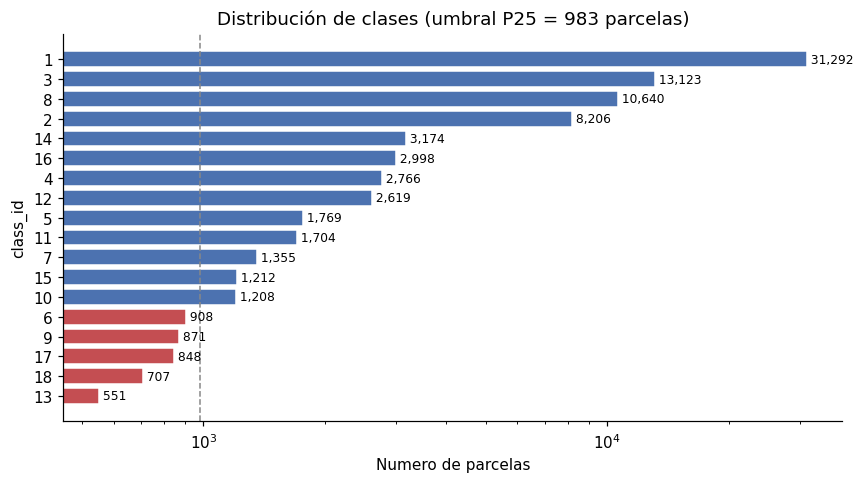

In [5]:
report = class_distribution_report(df)
display(report)
threshold = recommend_threshold(report, method='p25')
display(Markdown(f'Umbral sugerido (P25): `{threshold}` parcelas.'))

fig_class = plot_class_support_bars(
    report.rename({'n_parcels': 'len'}),
    weak_threshold=threshold,
    title=f'Distribución de clases (umbral P25 = {threshold} parcelas)',
)
fig_class.savefig(env.figures_dir / 'class_distribution.png', bbox_inches='tight')
display(fig_class)
plt.close(fig_class)


## 2. Por qué Random Forest, XGBoost y LightGBM

Se eligen **tres modelos de árboles** como referencia. Cinco razones sustentan la decisión:

**(a) Las imágenes ya vienen resumidas.** El embedding AlphaEarth de 64 dimensiones condensa información óptica, radar y temporal aprendida por un modelo entrenado sobre todo el archivo Sentinel. Sobre una representación ya rica, un modelo de árboles es un punto de referencia suficiente y honesto: no hace falta una red profunda para fijar el piso de desempeño (cf. Brown et al., 2025, *AlphaEarth Foundations*).

**(b) Son interpretables.** Random Forest expone la importancia Gini, XGBoost la ganancia (*gain*) y LightGBM la ganancia split-wise. Todos son compatibles con SHAP. Esto permite auditar qué variables explican las predicciones, no solo medir aciertos.

**(c) Tres familias de árboles, no una.** Random Forest (bagging) reduce varianza; XGBoost (boosting con regularización L1/L2) reduce sesgo; LightGBM (boosting con histogram-based splits y leaf-wise growth) entrena mucho más rápido sobre datasets grandes. Comparar las tres familias evita atribuir diferencias de F1 a un único algoritmo.

**(d) Validación cruzada espacial.** Cada modelo se evalúa con el mismo CV espacial 5-fold (celdas hexagonales H3 + agrupamiento KMeans + buffer 1 km), no con un split aleatorio. Esto evita que parcelas vecinas queden a la vez en train y test (leakage espacial garantizado en datos satelitales).

**(e) Reproducibilidad.** Los tres modelos comparten `random_state=42`, la misma matriz de features y las mismas particiones — la única variable que cambia es el algoritmo.

## 3. Entrenamiento con validación cruzada espacial

Tiempo de pared esperado: **30-60 minutos** (RF en CPU multinúcleo + XGBoost en GPU + LightGBM en CPU). El helper `train_baseline_three_models` materializa los folds una sola vez y los reusa entre modelos.

In [6]:
rows = train_baseline_three_models(
    df,
    models=('rf', 'xgb', 'lgbm'),
    k_folds=K_FOLDS,
    buffer_km=BUFFER_KM,
    random_state=RANDOM_STATE,
)
comparison_path = env.reports_dir / 'model_comparison_04.parquet'
comparison = build_model_comparison_table(rows, output_path=comparison_path)
display(Markdown(f'**Tabla guardada**: `{comparison_path.relative_to(env.repo)}`'))
display(comparison)

# MLflow: un run por modelo con metricas, params y tags estandar.
for r in rows:
    with track_experiment(
        experiment_name=MLFLOW_EXPERIMENT,
        run_name=f'04-{r.model}',
        tracking_uri=mlflow_uri,
        dvc_path=FEATURES_PATH,
        probe_server=False,
    ) as run:
        import mlflow
        mlflow.log_params({
            'model': r.model,
            'k_folds': K_FOLDS,
            'buffer_km': BUFFER_KM,
            'random_state': RANDOM_STATE,
            'n_parcels': df.height,
        })
        mlflow.log_metrics({
            'f1_macro': r.f1_macro,
            'f1_weighted': r.f1_weighted,
            'miou': r.miou,
            'accuracy': r.accuracy,
            'kappa': r.cohen_kappa,
            'train_time_s': r.train_time_s,
        })
        MLFLOW_RUN_IDS[r.model] = run.info.run_id
display(Markdown('**MLflow runs registrados**: ' + ', '.join(
    f'`{k}={v[:12]}...`' for k, v in MLFLOW_RUN_IDS.items()
)))


2026-05-29 19:30:54 [info     ] spatial_folds_cache_hit        n_folds=5 path=data/test_fixtures/baseline_spatial_folds_n85951_k5_b1_s42.parquet
2026-05-29 19:30:54 [info     ] spatial_cv_start               n_classes=18 n_folds=5
2026-05-29 19:30:54 [info     ] spatial_cv_fold_start          fold=1/5 n_test=23157 n_train=62794
2026-05-29 19:30:54 [info     ] scaler_persisted               n_features=185 n_train=62794 path=/tmp/tmpe0azazfc/fold_0_scaler.joblib version=v1
2026-05-29 19:31:25 [info     ] spatial_cv_fold_done           f1_macro=0.3895 fold=1/5
2026-05-29 19:31:25 [info     ] spatial_cv_fold_start          fold=2/5 n_test=8470 n_train=77481
2026-05-29 19:31:25 [info     ] scaler_persisted               n_features=185 n_train=77481 path=/tmp/tmp276a20e_/fold_1_scaler.joblib version=v1
2026-05-29 19:32:03 [info     ] spatial_cv_fold_done           f1_macro=0.3427 fold=2/5
2026-05-29 19:32:03 [info     ] spatial_cv_fold_start          fold=3/5 n_test=22838 n_train=63113
2026-

/home/artzizumbo_gmail_com/.cache/pypoetry/virtualenvs/agrosatcopilot-s31b4B1H-py3.12/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [19:35:15] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


2026-05-29 19:35:16 [info     ] spatial_cv_fold_done           f1_macro=0.4516 fold=1/5
2026-05-29 19:35:16 [info     ] spatial_cv_fold_start          fold=2/5 n_test=8470 n_train=77481
2026-05-29 19:35:16 [info     ] scaler_persisted               n_features=185 n_train=77481 path=/tmp/tmpnfdnj1ob/fold_1_scaler.joblib version=v1
2026-05-29 19:35:17 [info     ] xgb_device_resolved            device=cuda gpu='NVIDIA L4'
2026-05-29 19:36:07 [info     ] spatial_cv_fold_done           f1_macro=0.3825 fold=2/5
2026-05-29 19:36:07 [info     ] spatial_cv_fold_start          fold=3/5 n_test=22838 n_train=63113
2026-05-29 19:36:07 [info     ] scaler_persisted               n_features=185 n_train=63113 path=/tmp/tmpovi9lwy2/fold_2_scaler.joblib version=v1
2026-05-29 19:36:08 [info     ] xgb_device_resolved            device=cuda gpu='NVIDIA L4'
2026-05-29 19:36:54 [info     ] spatial_cv_fold_done           f1_macro=0.4082 fold=3/5
2026-05-29 19:36:54 [info     ] spatial_cv_fold_start          fo

/home/artzizumbo_gmail_com/.cache/pypoetry/virtualenvs/agrosatcopilot-s31b4B1H-py3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


2026-05-29 19:41:54 [info     ] spatial_cv_fold_done           f1_macro=0.433 fold=1/5
2026-05-29 19:41:54 [info     ] spatial_cv_fold_start          fold=2/5 n_test=8470 n_train=77481
2026-05-29 19:41:54 [info     ] scaler_persisted               n_features=185 n_train=77481 path=/tmp/tmpnqplx7zz/fold_1_scaler.joblib version=v1


...

**Tabla guardada**: `reports/baseline/04_baseline/model_comparison_04.parquet`

model,f1_macro,f1_weighted,miou,accuracy,cohen_kappa,train_time_s,n_features,n_samples
str,f64,f64,f64,f64,f64,f64,i64,i64
"""xgb""",0.4109,0.6919,0.3126,0.7259,0.6547,304.4,185,85951
"""lgbm""",0.3901,0.6834,0.299,0.7244,0.6495,929.7,185,85951
"""rf""",0.365,0.6583,0.2699,0.6724,0.5961,210.4,185,85951


/home/artzizumbo_gmail_com/.cache/pypoetry/virtualenvs/agrosatcopilot-s31b4B1H-py3.12/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/29 19:54:58 INFO mlflow.tracking.fluent: Experiment with name 'baseline-04-tabular' does not exist. Creating a new experiment.


2026-05-29 19:54:59 [info     ] mlflow_run_started             code_version=ea8fb07c10a9313327c206882649e37b9b69d1af data_version=data/test_fixtures/feature_selection_parcels_subset.parquet@4f49f4f2d22013d7ccad787727119bac experiment=baseline-04-tabular run_id=6a247058909b458a853b4d0b469a7a11 run_name=04-rf tracking_uri=file:./mlruns
2026-05-29 19:54:59 [info     ] mlflow_run_started             code_version=ea8fb07c10a9313327c206882649e37b9b69d1af data_version=data/test_fixtures/feature_selection_parcels_subset.parquet@4f49f4f2d22013d7ccad787727119bac experiment=baseline-04-tabular run_id=84d43639fc9b4093aeeeb1a4c72091c8 run_name=04-xgb tracking_uri=file:./mlruns
2026-05-29 19:54:59 [info     ] mlflow_run_started             code_version=ea8fb07c10a9313327c206882649e37b9b69d1af data_version=data/test_fixtures/feature_selection_parcels_subset.parquet@4f49f4f2d22013d7ccad787727119bac experiment=baseline-04-tabular run_id=6ed39ef7698c42a6a2a41e9218e8ff5b run_name=04-lgbm tracking_uri=fil

**MLflow runs registrados**: `rf=6a247058909b...`, `xgb=84d43639fc9b...`, `lgbm=6ed39ef7698c...`

### 3.1 Comparativa F1-macro entre los tres modelos

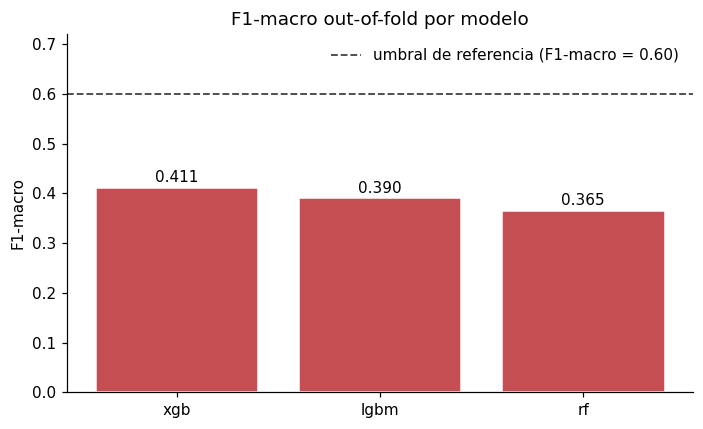

In [7]:
metric_by_model = {r.model: r.f1_macro for r in rows}
fig_cmp = plot_model_comparison_bars(
    metric_by_model,
    baseline_value=F1_THRESHOLD,
    baseline_label=f'umbral de referencia (F1-macro = {F1_THRESHOLD:.2f})',
    title='F1-macro out-of-fold por modelo',
)
fig_cmp.savefig(env.figures_dir / 'model_comparison.png', bbox_inches='tight')
display(fig_cmp)
plt.close(fig_cmp)


## 4. Modelo ganador — matriz de confusión y F1 por clase

El modelo ganador (mayor F1-macro out-of-fold) se reentrena para conseguir las predicciones out-of-fold completas. A partir de ellas se construyen la matriz de confusión normalizada por fila y el F1 por clase, que identifican qué clases concentran el error y cuáles están bien resueltas.

El modelo serializado se guarda en `reports/baseline/04_baseline/best_model_*.joblib` para reutilizarlo desde `Avance3.Equipo17.ipynb`.

Modelo ganador: `xgb` (F1-macro `0.4109`)

2026-05-29 19:56:50 [info     ] spatial_folds_cache_hit        n_folds=5 path=data/test_fixtures/baseline_spatial_folds_n85951_k5_b1_s42.parquet
2026-05-29 19:56:50 [info     ] spatial_cv_start               n_classes=18 n_folds=5
2026-05-29 19:56:50 [info     ] spatial_cv_fold_start          fold=1/5 n_test=23157 n_train=62794
2026-05-29 19:56:51 [info     ] scaler_persisted               n_features=185 n_train=62794 path=/tmp/tmpukp9n1p5/fold_0_scaler.joblib version=v1
2026-05-29 19:56:51 [info     ] xgb_device_resolved            device=cuda gpu='NVIDIA L4'
2026-05-29 19:57:38 [info     ] spatial_cv_fold_done           f1_macro=0.4516 fold=1/5
2026-05-29 19:57:38 [info     ] spatial_cv_fold_start          fold=2/5 n_test=8470 n_train=77481
2026-05-29 19:57:38 [info     ] scaler_persisted               n_features=185 n_train=77481 path=/tmp/tmp7ra8dbjl/fold_1_scaler.joblib version=v1
2026-05-29 19:57:39 [info     ] xgb_device_resolved            device=cuda gpu='NVIDIA L4'
2026-05-29

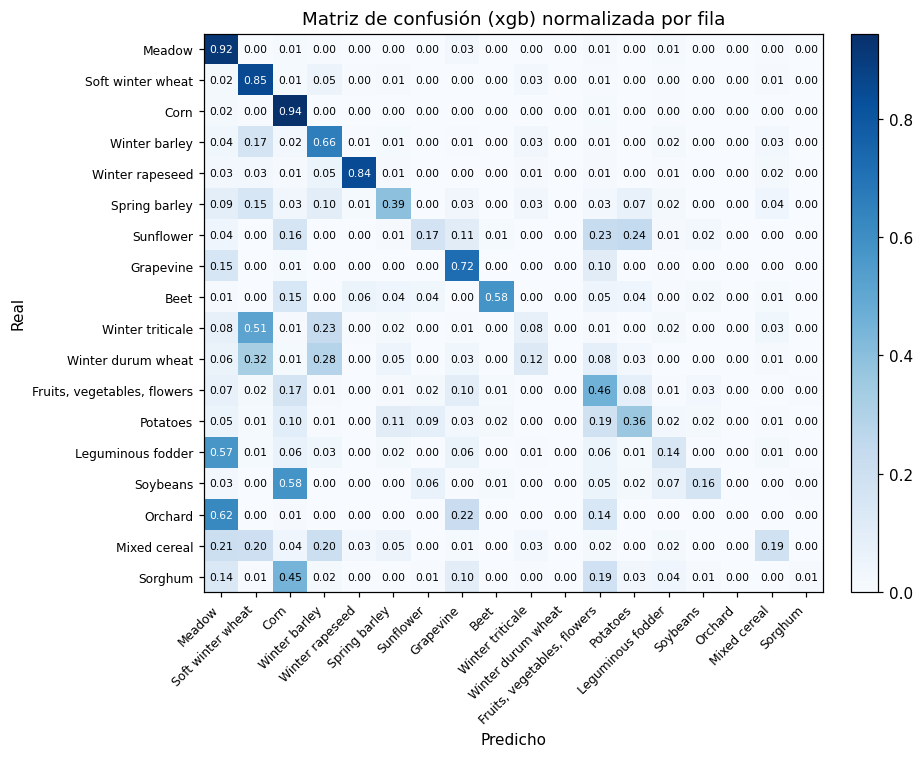

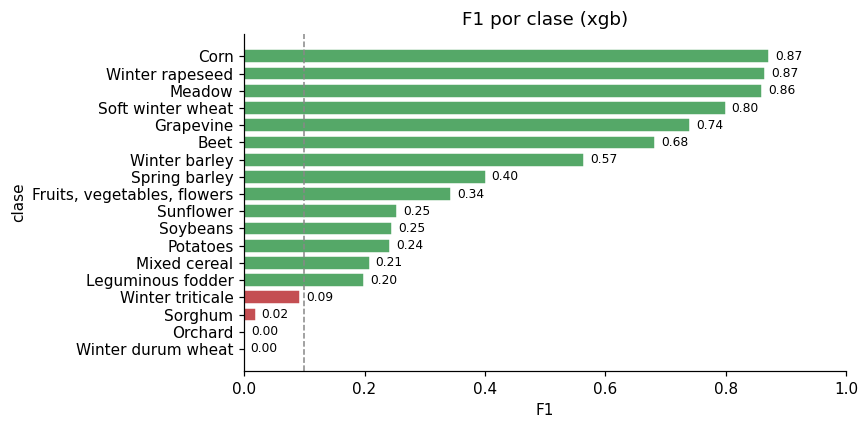

Modelo guardado en `reports/baseline/04_baseline/best_model_xgb.joblib`

In [8]:
from ml.train.baseline import (
    train_one_model,
    evaluate_with_spatial_cv,
    build_estimator,
)
best_model = comparison['model'][0]
best_f1 = float(comparison['f1_macro'][0])
display(Markdown(
    f'Modelo ganador: `{best_model}` (F1-macro `{best_f1:.4f}`)'
))

# train_one_model solo acepta 'rf' o 'xgb'. Si gana LGBM, usamos
# XGBoost como modelo interpretable (es la familia mas cercana).
interpretable_kind = best_model if best_model in ('rf', 'xgb') else 'xgb'
if interpretable_kind != best_model:
    display(Markdown(
        f'> Nota: las secciones 5 y 6 (importancia, SHAP, curvas) usan '
        f'`{interpretable_kind}` como sustituto interpretable de `{best_model}` '
        '(el helper SHAP del proyecto solo soporta RF y XGB).'
    ))

best_result = train_one_model(
    df,
    model=interpretable_kind,
    k_folds=K_FOLDS,
    buffer_km=BUFFER_KM,
    random_state=RANDOM_STATE,
)
_, y_true_oof, y_pred_oof = evaluate_with_spatial_cv(
    df,
    lambda: build_estimator(interpretable_kind, best_result.best_params),
    k_folds=K_FOLDS,
    buffer_km=BUFFER_KM,
    random_state=RANDOM_STATE,
)

class_names_decoded = {
    i: PASTIS_R_CLASSES.get(int(c), f'c{int(c)}')
    for i, c in enumerate(best_result.label_classes)
}

fig_cm = plot_confusion_matrix_heatmap(
    y_true_oof,
    y_pred_oof,
    class_labels=list(range(len(best_result.label_classes))),
    class_names=class_names_decoded,
    normalize='true',
    title=f'Matriz de confusión ({interpretable_kind}) normalizada por fila',
)
fig_cm.savefig(env.figures_dir / 'confusion_matrix.png', bbox_inches='tight')
display(fig_cm)
plt.close(fig_cm)

fig_f1 = plot_per_class_f1(
    y_true_oof,
    y_pred_oof,
    class_labels=list(range(len(best_result.label_classes))),
    class_names=class_names_decoded,
    weak_threshold=0.10,
    title=f'F1 por clase ({interpretable_kind})',
)
fig_f1.savefig(env.figures_dir / 'per_class_f1.png', bbox_inches='tight')
display(fig_f1)
plt.close(fig_f1)

import joblib
joblib_path = env.reports_dir / f'best_model_{best_model}.joblib'
joblib.dump(best_result, joblib_path)
display(Markdown(f'Modelo guardado en `{joblib_path.relative_to(env.repo)}`'))


## 5. Importancia de características y análisis SHAP

Random Forest y XGBoost exponen una medida de importancia sin coste adicional: **Gini** para Random Forest y **gain** para XGBoost. Es el primer diagnóstico de interpretabilidad — barato y directo — antes del análisis SHAP.

**SHAP** (Lundberg & Lee, 2017) descompone cada predicción en contribuciones aditivas por característica con garantías teóricas de consistencia. Para modelos de árboles se usa el algoritmo **TreeSHAP**, que es exacto. Se calcula sobre un subsample estratificado (`SHAP_SAMPLE_SIZE` parcelas) porque el coste de TreeSHAP crece con el número de muestras, árboles y profundidad.

In [9]:
from ml.eval.interpretability import (
    feature_importance_table,
    compute_shap_values,
    shap_summary_plot,
    shap_dependence_plots,
    shap_waterfall_plot,
    alphaearth_dominance_table,
)

# Entrenamos ambos modelos interpretables (RF y XGB) sobre el dataset
# completo para tener la importancia nativa y SHAP de los dos.
interpretable_models = {}
for kind in ('rf', 'xgb'):
    res = train_one_model(
        df,
        model=kind,
        k_folds=K_FOLDS,
        buffer_km=BUFFER_KM,
        random_state=RANDOM_STATE,
    )
    interpretable_models[kind] = res
    display(Markdown(
        f'- `{kind}` ajustado sobre `{df.height:,}` parcelas con '
        f'`{len(res.feature_cols)}` features.'
    ))


2026-05-29 20:06:48 [info     ] spatial_folds_cache_hit        n_folds=5 path=data/test_fixtures/baseline_spatial_folds_n85951_k5_b1_s42.parquet
2026-05-29 20:06:48 [info     ] spatial_cv_start               n_classes=18 n_folds=5
2026-05-29 20:06:48 [info     ] spatial_cv_fold_start          fold=1/5 n_test=23157 n_train=62794
2026-05-29 20:06:49 [info     ] scaler_persisted               n_features=185 n_train=62794 path=/tmp/tmpi9go0s84/fold_0_scaler.joblib version=v1
2026-05-29 20:07:18 [info     ] spatial_cv_fold_done           f1_macro=0.3895 fold=1/5
2026-05-29 20:07:18 [info     ] spatial_cv_fold_start          fold=2/5 n_test=8470 n_train=77481
2026-05-29 20:07:19 [info     ] scaler_persisted               n_features=185 n_train=77481 path=/tmp/tmpa88pnvhi/fold_1_scaler.joblib version=v1
2026-05-29 20:07:57 [info     ] spatial_cv_fold_done           f1_macro=0.3427 fold=2/5
2026-05-29 20:07:57 [info     ] spatial_cv_fold_start          fold=3/5 n_test=22838 n_train=63113
2026-

- `rf` ajustado sobre `85,951` parcelas con `185` features.

2026-05-29 20:10:18 [info     ] spatial_folds_cache_hit        n_folds=5 path=data/test_fixtures/baseline_spatial_folds_n85951_k5_b1_s42.parquet
2026-05-29 20:10:18 [info     ] spatial_cv_start               n_classes=18 n_folds=5
2026-05-29 20:10:18 [info     ] spatial_cv_fold_start          fold=1/5 n_test=23157 n_train=62794
2026-05-29 20:10:18 [info     ] scaler_persisted               n_features=185 n_train=62794 path=/tmp/tmpcg86brpf/fold_0_scaler.joblib version=v1
2026-05-29 20:10:19 [info     ] xgb_device_resolved            device=cuda gpu='NVIDIA L4'
2026-05-29 20:11:05 [info     ] spatial_cv_fold_done           f1_macro=0.4516 fold=1/5
2026-05-29 20:11:05 [info     ] spatial_cv_fold_start          fold=2/5 n_test=8470 n_train=77481
2026-05-29 20:11:06 [info     ] scaler_persisted               n_features=185 n_train=77481 path=/tmp/tmpw9v6al2s/fold_1_scaler.joblib version=v1
2026-05-29 20:11:07 [info     ] xgb_device_resolved            device=cuda gpu='NVIDIA L4'
2026-05-29

- `xgb` ajustado sobre `85,951` parcelas con `185` features.

### 5.1 Importancia nativa — top-20 por modelo

2026-05-29 20:15:45 [info     ] feature_importance_table_computed model_kind=rf n_features=185 top_feature=EVI_fft_phase_2


**Importancia nativa `rf`** (Gini). Guardada en `reports/baseline/04_baseline/feature_importance_rf.csv`.

feature,importance,rank
str,f64,i64
"""EVI_fft_phase_2""",0.026526,1
"""NDVI_fft_phase_2""",0.022583,2
"""EVI_fft_phase_3""",0.02236,3
"""EVI_fft_phase_1""",0.020502,4
"""MCARI_p95""",0.019526,5
"""NDWI_fft_phase_1""",0.016265,6
"""NDMI_p75""",0.016079,7
"""MSAVI2_min""",0.015561,8
"""NDVI_fft_phase_1""",0.015079,9


2026-05-29 20:15:45 [info     ] feature_importance_table_computed model_kind=xgb n_features=185 top_feature=MSAVI2_min


**Importancia nativa `xgb`** (gain). Guardada en `reports/baseline/04_baseline/feature_importance_xgb.csv`.

feature,importance,rank
str,f64,i64
"""MSAVI2_min""",39.577316,1
"""GCVI_p50""",33.774689,2
"""SAVI_std""",33.544697,3
"""TSAVI_p25""",26.019739,4
"""EVI_fft_phase_2""",19.242167,5
"""EVI_fft_phase_1""",17.154438,6
"""NDMI_p95""",15.997797,7
"""GCVI_p25""",14.699634,8
"""NDRE_p95""",13.877607,9


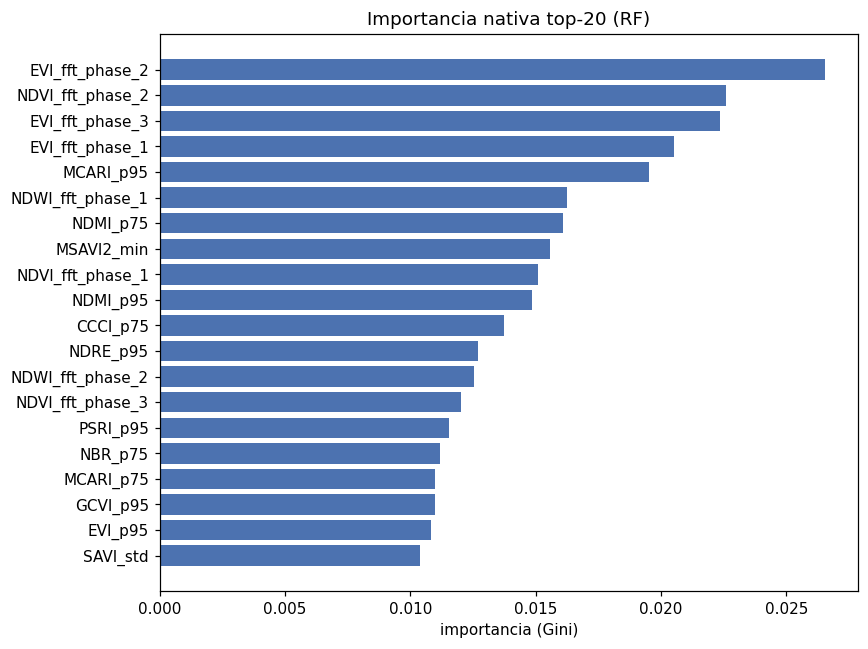

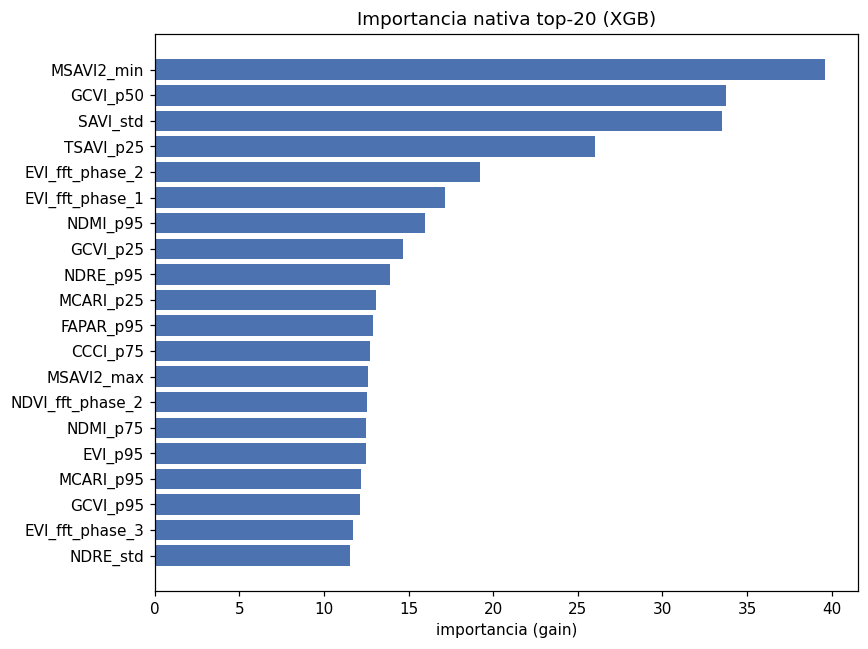

In [10]:
importance_tables = {}
for kind, res in interpretable_models.items():
    table = feature_importance_table(
        res.model,
        model_kind=kind,
        feature_cols=tuple(res.feature_cols),
    )
    importance_tables[kind] = table
    csv_path = env.reports_dir / f'feature_importance_{kind}.csv'
    table.write_csv(csv_path)
    display(Markdown(
        f'**Importancia nativa `{kind}`** ({"Gini" if kind == "rf" else "gain"}). '
        f'Guardada en `{csv_path.relative_to(env.repo)}`.'
    ))
    display(table.head(TOP_FEATURES_DISPLAY))

# Barplot horizontal top-20 por modelo.
import numpy as np
for kind, table in importance_tables.items():
    top = table.head(TOP_FEATURES_DISPLAY)
    fig, ax = plt.subplots(figsize=(8, 6), dpi=110)
    ax.barh(top['feature'].to_list()[::-1], top['importance'].to_list()[::-1], color='#4C72B0')
    ax.set_xlabel('importancia (Gini)' if kind == 'rf' else 'importancia (gain)')
    ax.set_title(f'Importancia nativa top-{TOP_FEATURES_DISPLAY} ({kind.upper()})')
    fig.tight_layout()
    fig.savefig(env.figures_dir / f'feature_importance_{kind}.png', bbox_inches='tight')
    display(fig)
    plt.close(fig)


### 5.2 SHAP — beeswarm global, dependence plots y waterfall

2026-05-29 20:50:53 [info     ] shap_values_computed           model_kind=rf n_classes=18 n_features=185 n_samples=3000 sample_rows=3000


- SHAP `rf`: tensor `(3000, 185, 18)` (muestras, features, clases).

2026-05-29 20:51:02 [info     ] shap_values_computed           model_kind=xgb n_classes=18 n_features=185 n_samples=3000 sample_rows=3000


- SHAP `xgb`: tensor `(3000, 185, 18)` (muestras, features, clases).

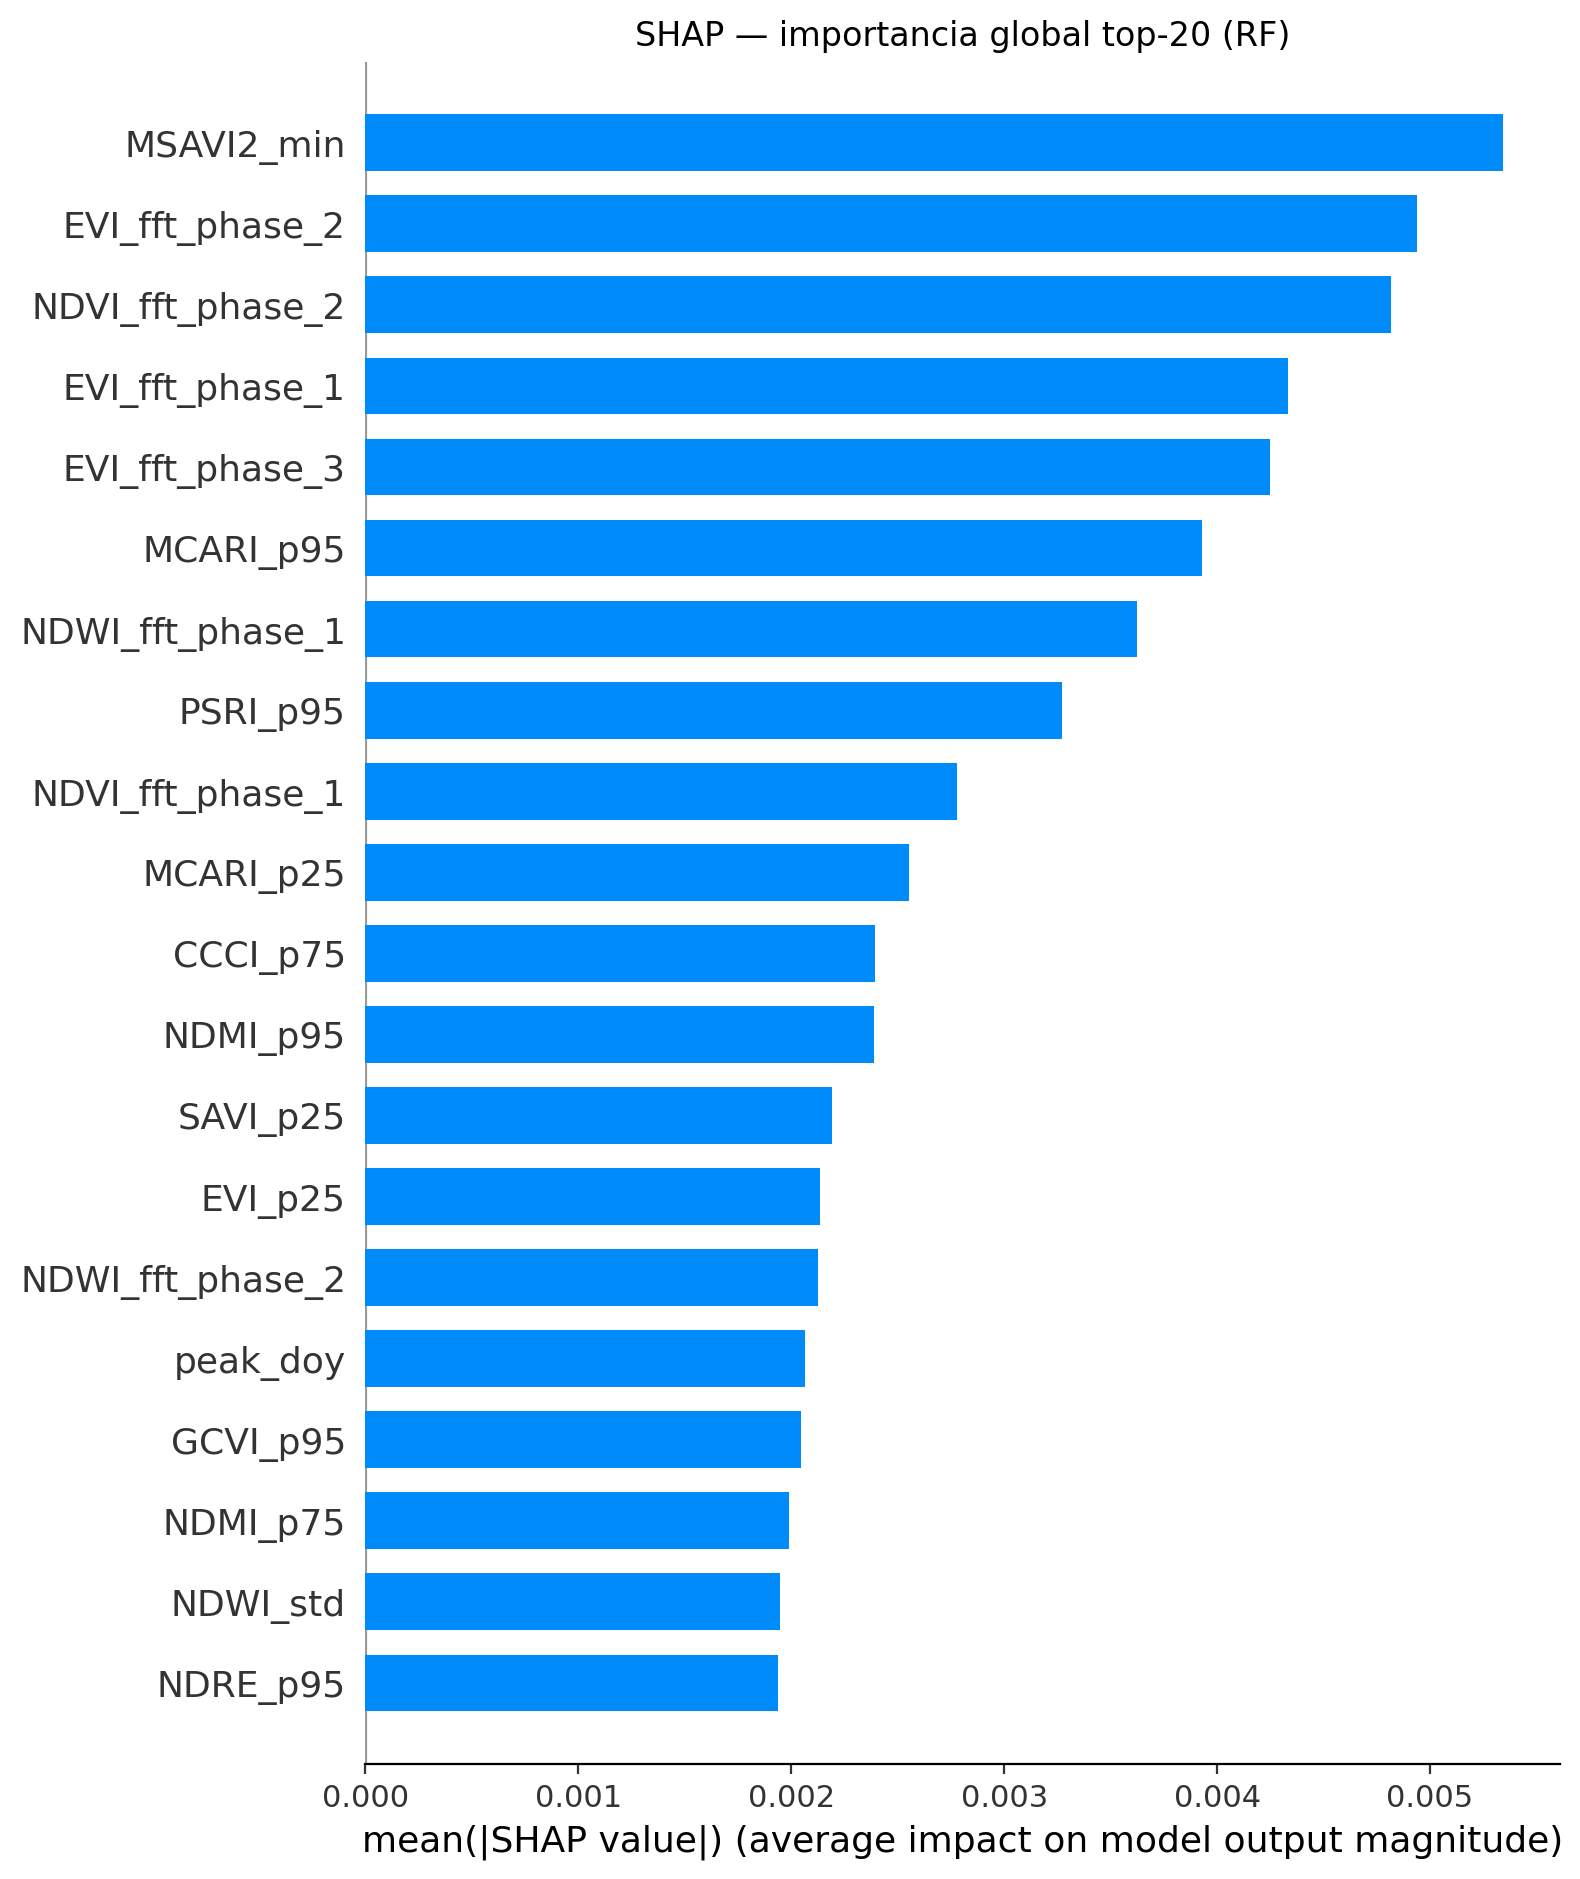

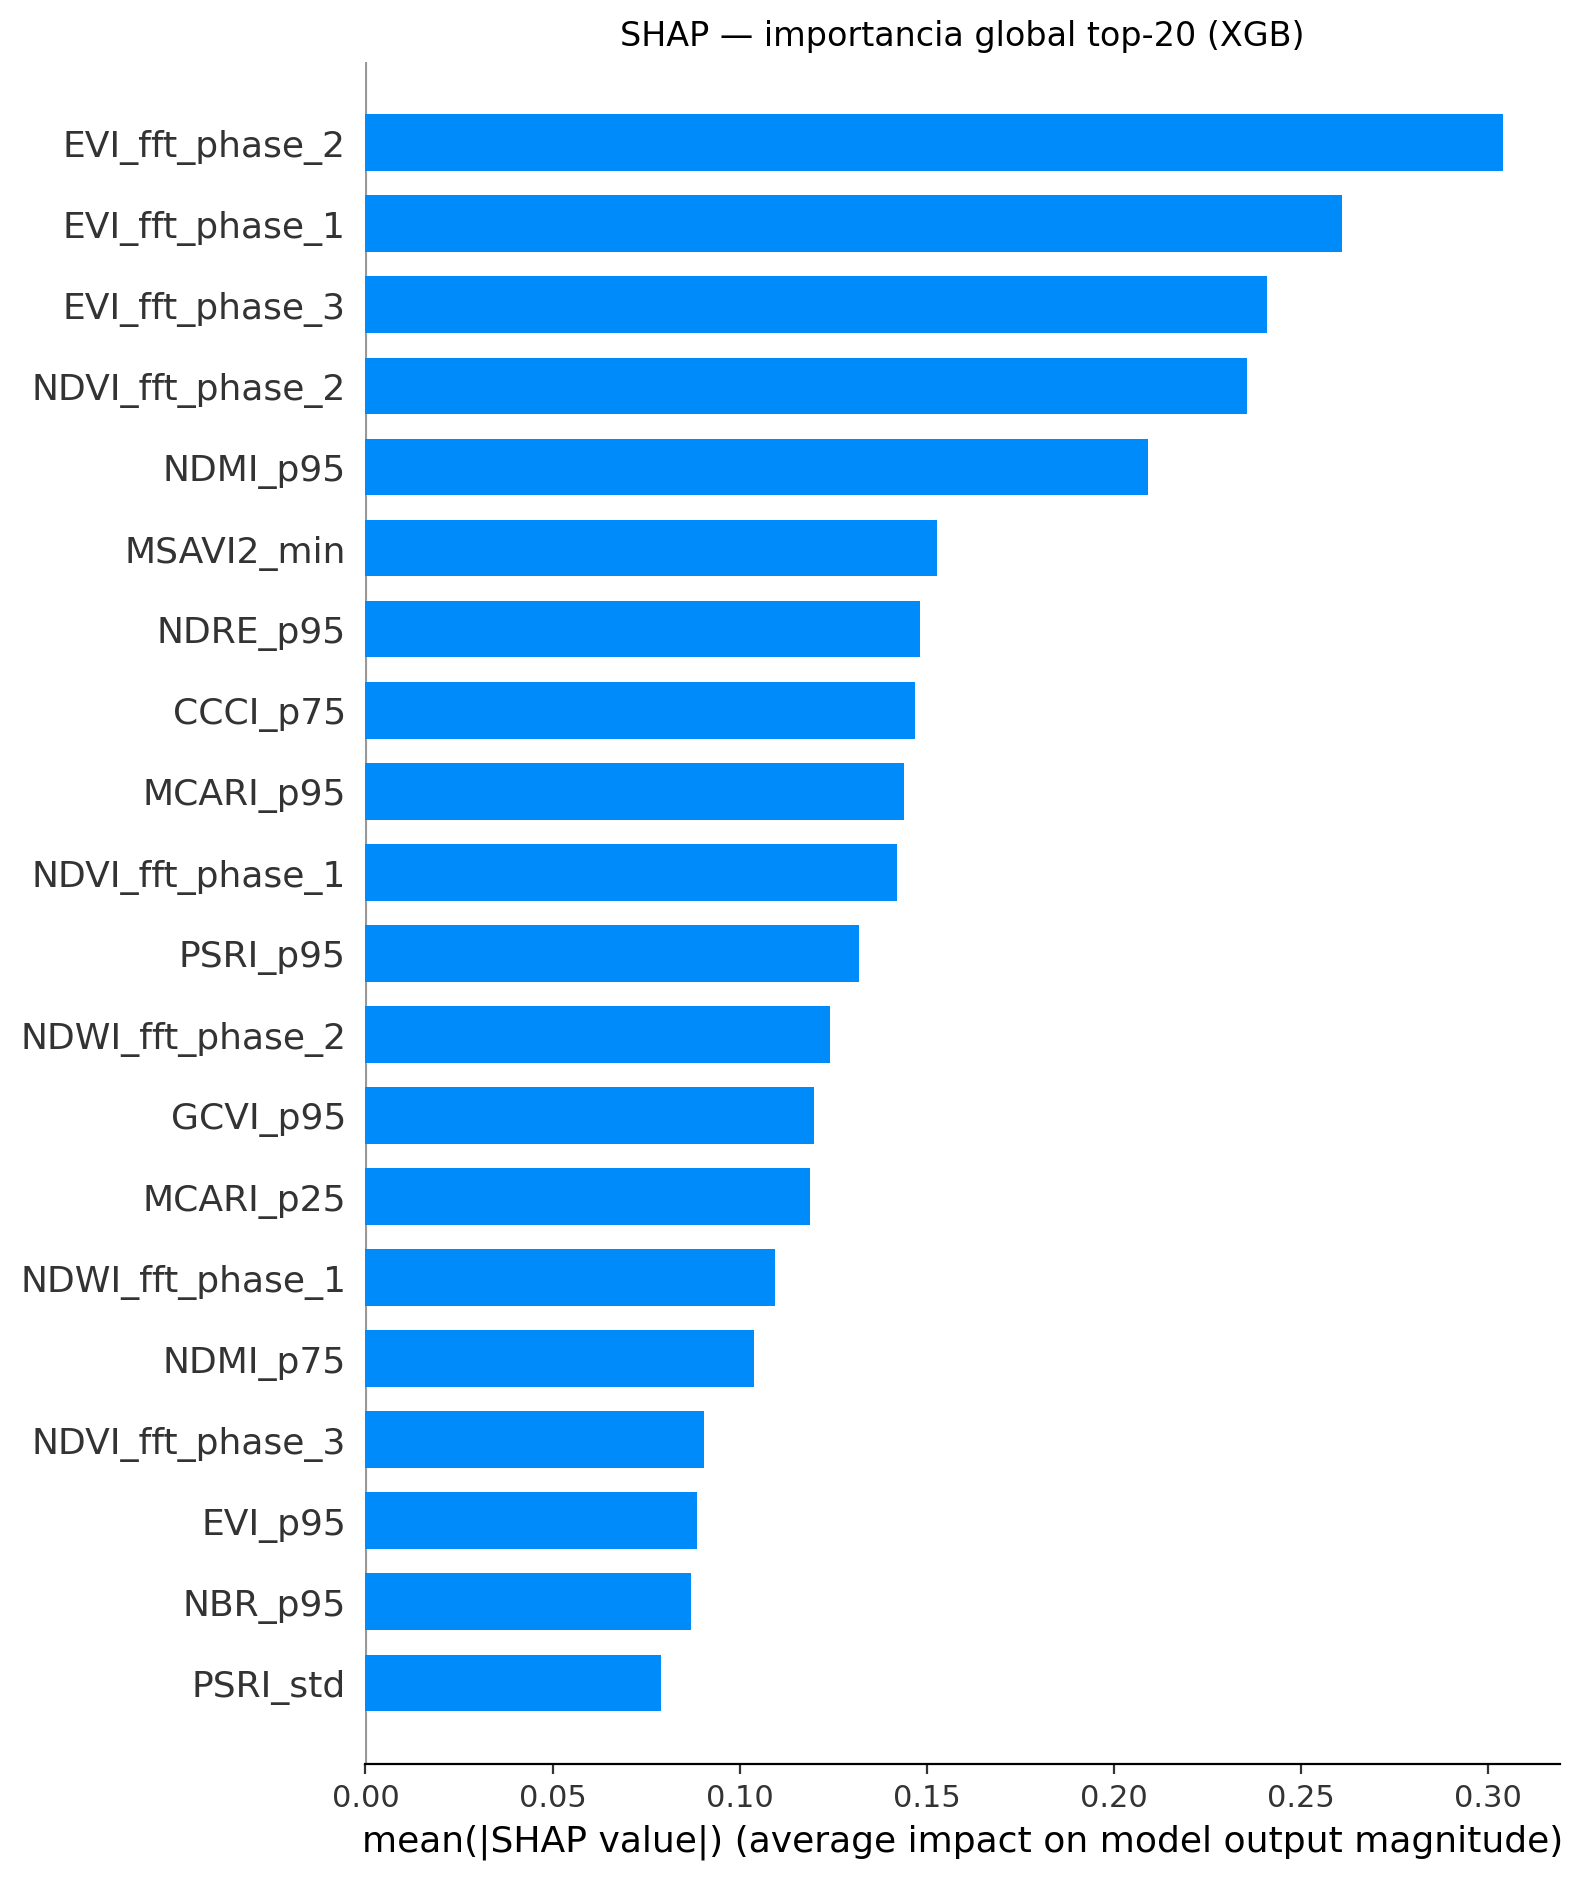

In [11]:
shap_results = {}
for kind, res in interpretable_models.items():
    feature_cols = tuple(res.feature_cols)
    X_for_shap = df.select(list(feature_cols))
    shap_results[kind] = compute_shap_values(
        res.model,
        X_for_shap,
        model_kind=kind,
        feature_cols=feature_cols,
        sample_size=SHAP_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
    )
    display(Markdown(
        f'- SHAP `{kind}`: tensor `{shap_results[kind].values.shape}` '
        f'(muestras, features, clases).'
    ))

# Summary plot (beeswarm/bar) top-20 global por modelo.
for kind, sr in shap_results.items():
    fig = shap_summary_plot(sr, df.select(list(sr.feature_cols)), top_n=TOP_FEATURES_DISPLAY)
    fig.savefig(env.figures_dir / f'shap_summary_{kind}.png', bbox_inches='tight')
    display(fig)
    plt.close(fig)


**Lectura del SHAP summary**: cada barra agrega la magnitud absoluta media del impacto SHAP por feature, promediada sobre todas las clases. Una barra larga indica que esa característica desplaza con fuerza la predicción — hacia o lejos de la clase, según el signo. Es la mejor manera de leer el ranking global sin perder la dirección del efecto en cada clase.

2026-05-29 20:52:42 [info     ] shap_dependence_plots_generated class_idx=0 model_kind=rf n_plots=5


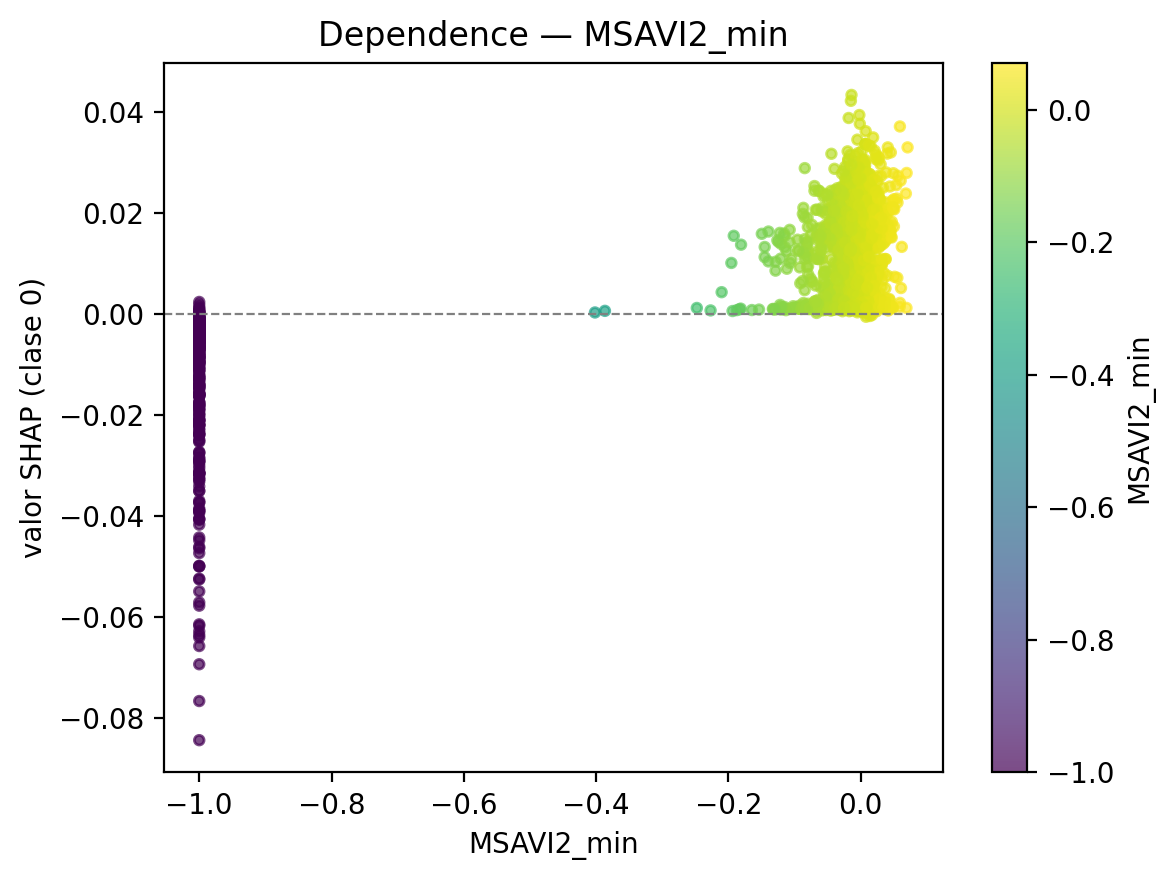

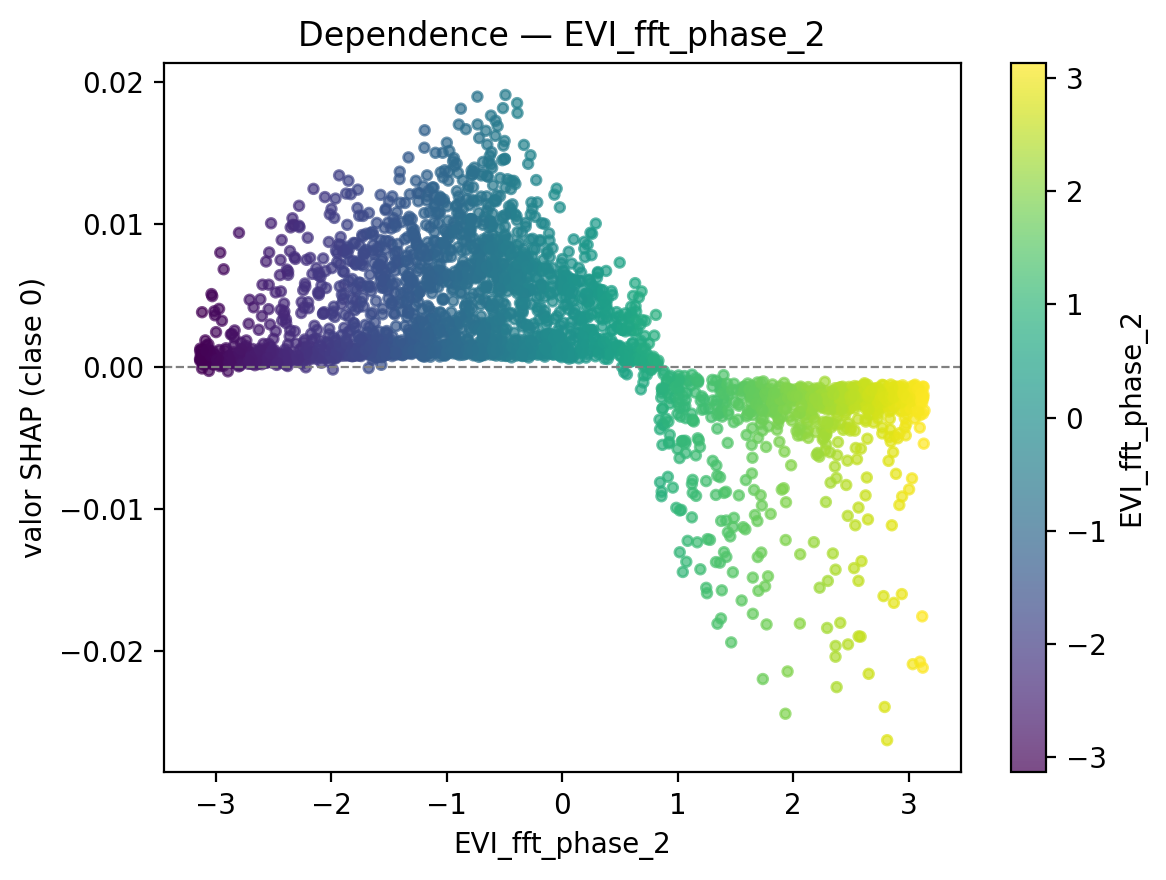

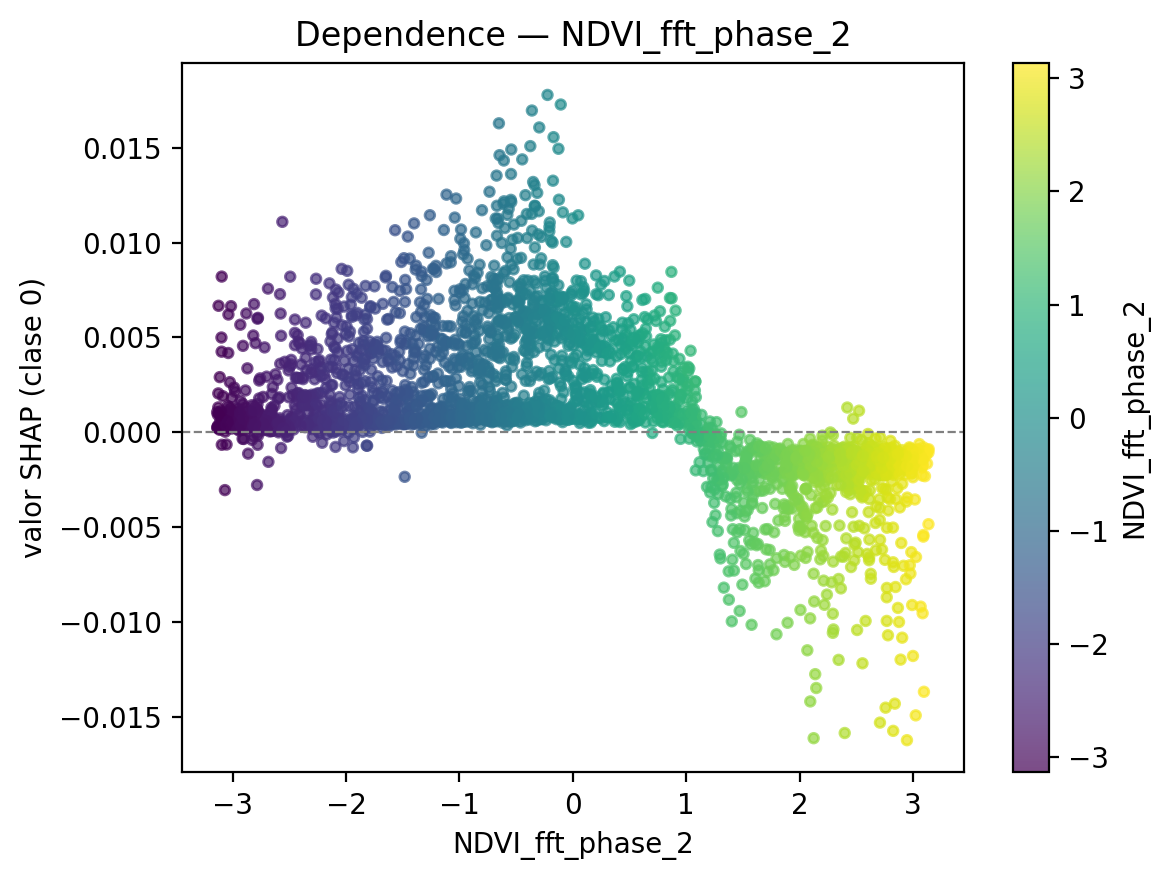

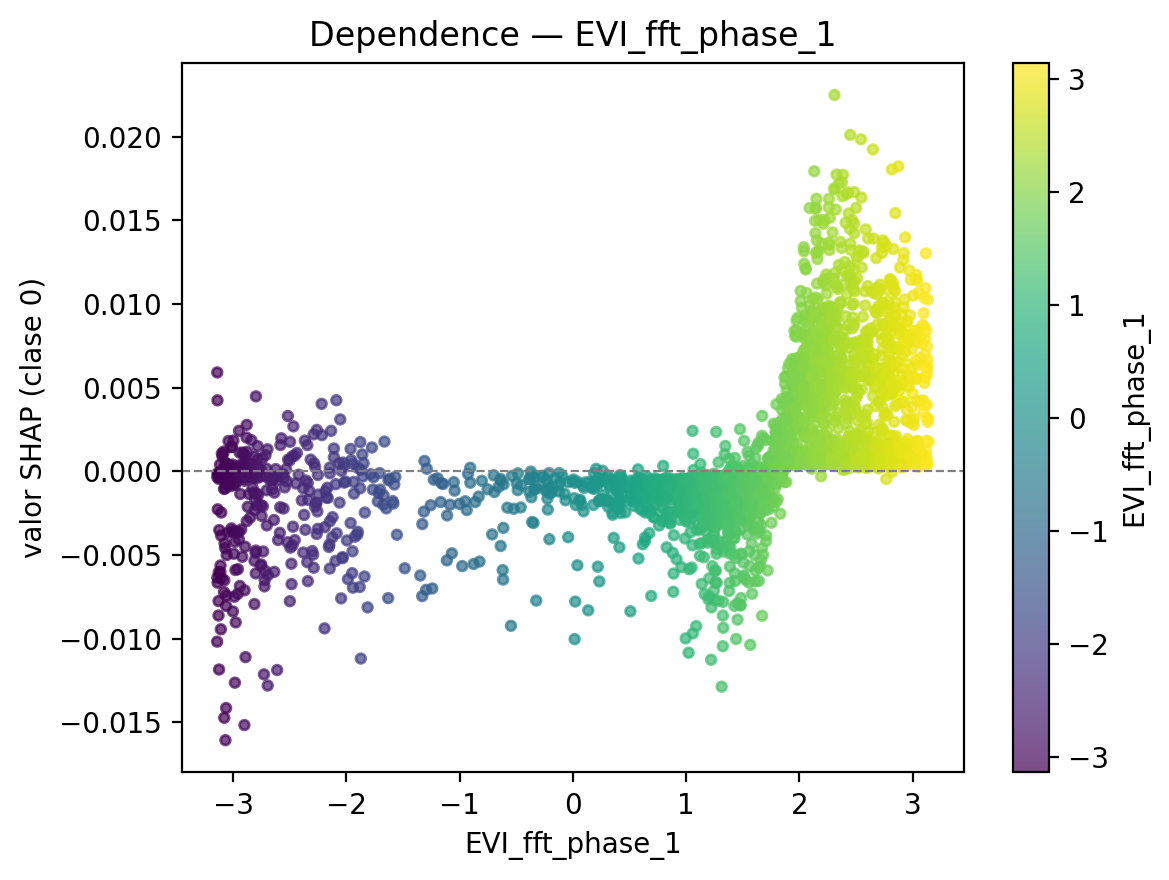

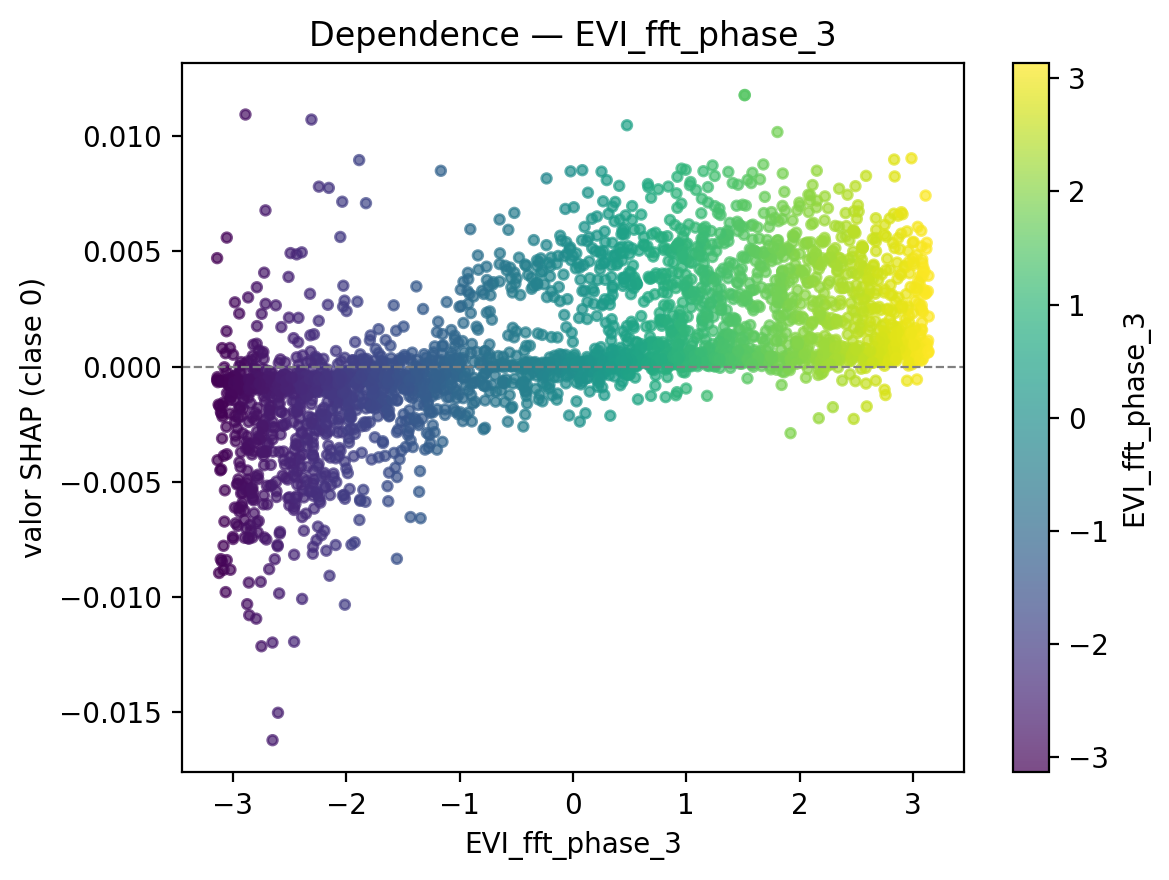

In [12]:
# Dependence plots de las top-5 features (modelo principal: el que mas vario
# en importancia, por convencion RF).
primary = 'rf'
dependence = shap_dependence_plots(
    shap_results[primary],
    df.select(list(shap_results[primary].feature_cols)),
    top_features=5,
)
for feature_name, fig in dependence:
    fig.savefig(
        env.figures_dir / f'shap_dependence_{primary}_{feature_name}.png',
        bbox_inches='tight',
    )
    display(fig)
    plt.close(fig)


**Lectura de los dependence plots**: el eje X es el valor del feature y el eje Y es el valor SHAP de ese feature para cada parcela. Una pendiente clara indica un efecto monótono (el feature empuja la predicción de forma proporcional); una nube sin estructura indica que el efecto depende de interacciones con otras features y no es interpretable aislado.

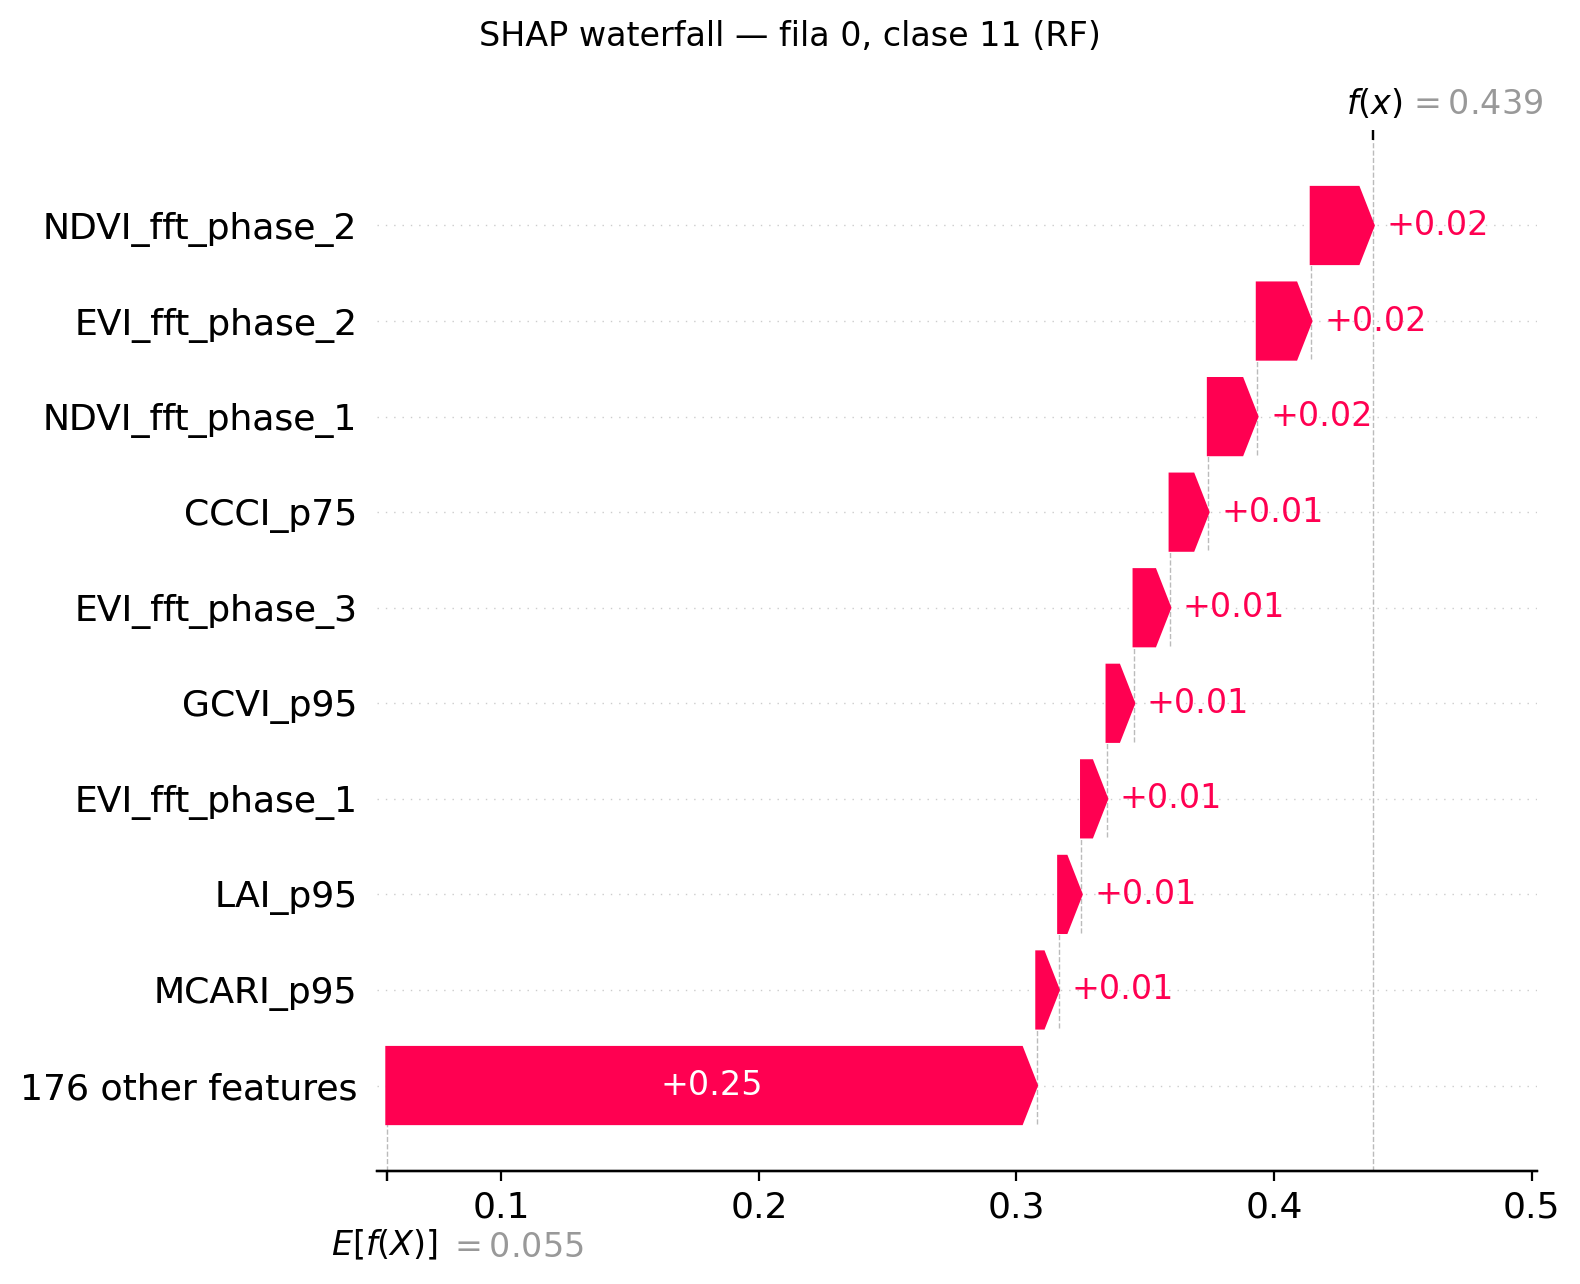

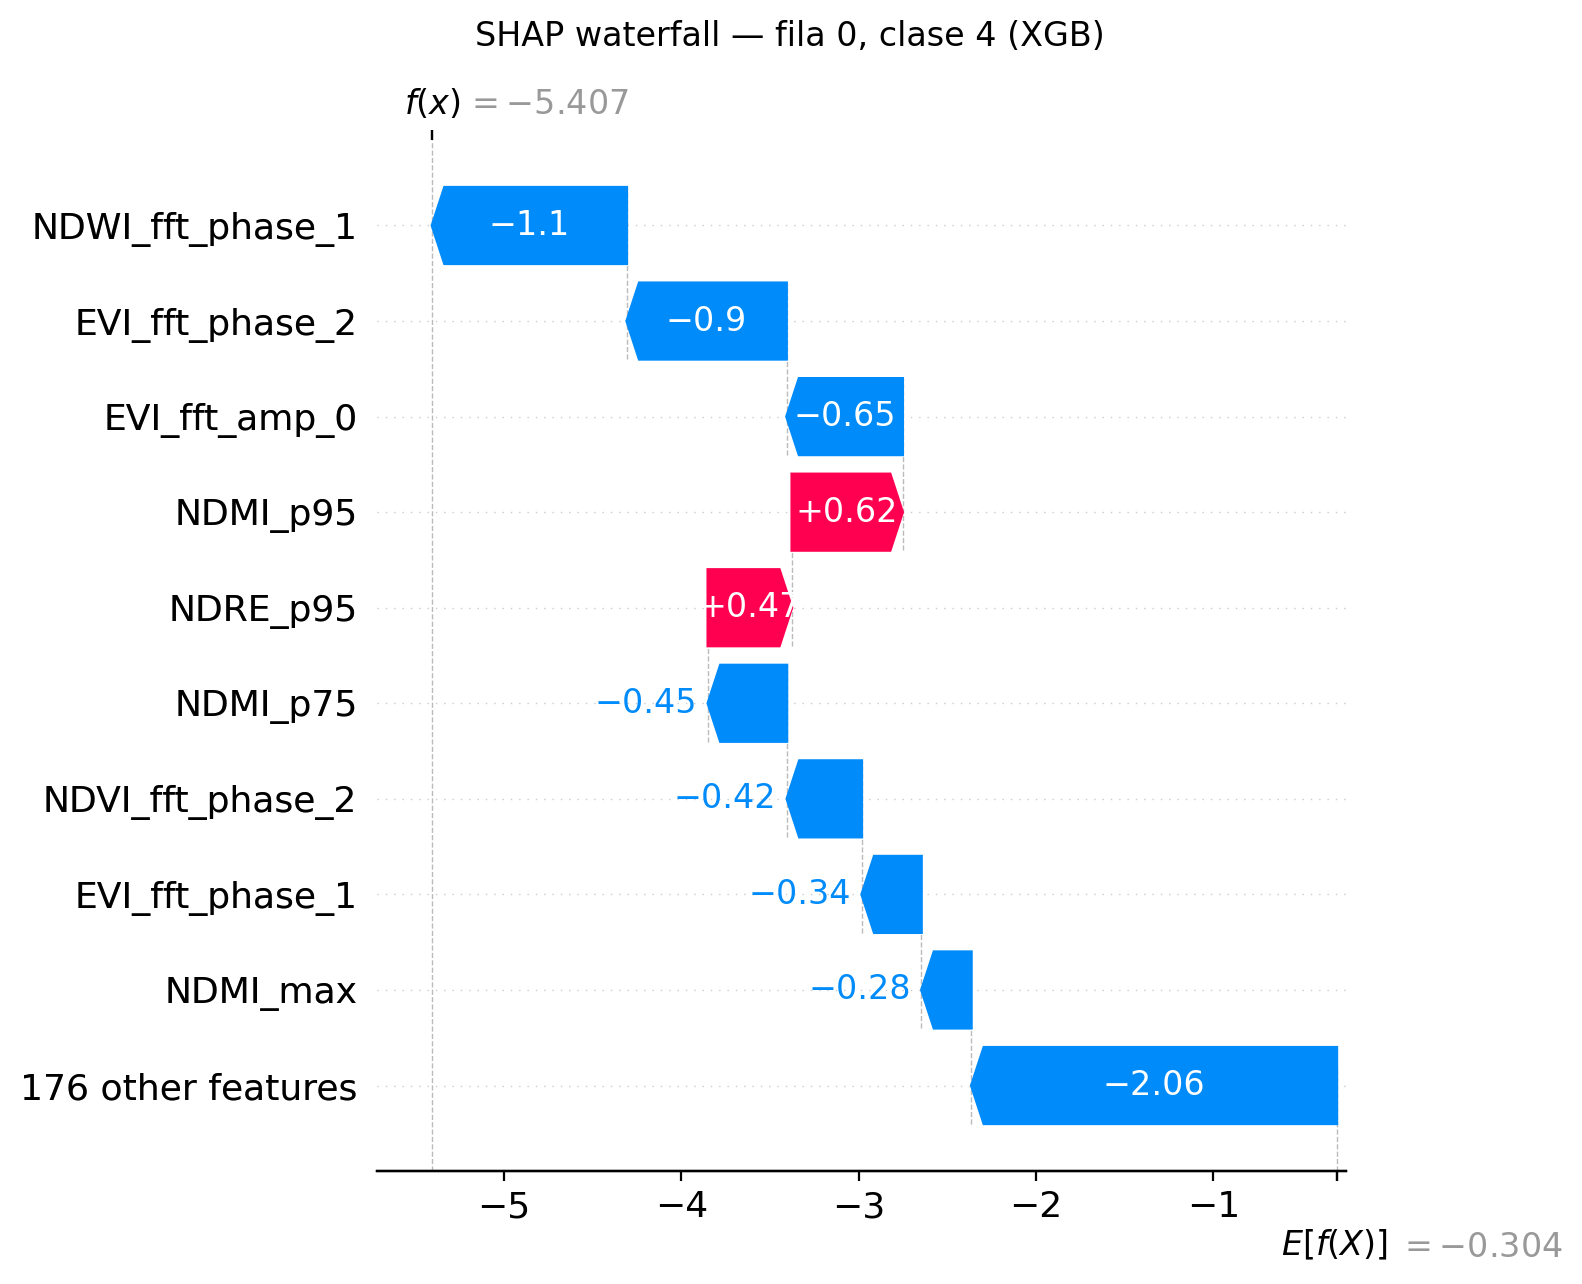

In [13]:
# Waterfall de una prediccion ejemplo por modelo.
for kind, sr in shap_results.items():
    fig = shap_waterfall_plot(sr, row=0)
    fig.savefig(env.figures_dir / f'shap_waterfall_{kind}.png', bbox_inches='tight')
    display(fig)
    plt.close(fig)


### 5.3 Dominancia de las dimensiones AlphaEarth

De las características más influyentes según SHAP, **¿cuántas son dimensiones del embedding AlphaEarth (`dim_00..dim_63`)** frente a índices espectrales, estadísticas temporales o bloques de contexto (radar, terreno, clima)? La respuesta cuantifica cuánto del poder predictivo proviene del embedding satelital frente al resto. Si dominan, AlphaEarth está haciendo el trabajo principal; si no, el feature engineering espectro-temporal sigue siendo imprescindible.

In [14]:
dominance_tables = {}
for kind, sr in shap_results.items():
    dom = alphaearth_dominance_table(
        sr.global_importance,
        top_n=TOP_FEATURES_DISPLAY,
    )
    dominance_tables[kind] = dom
    family_counts = (
        dom.group_by('family').len().sort('len', descending=True)
    )
    n_ae = int(family_counts.filter(pl.col('family') == 'alphaearth')['len'].sum())
    display(Markdown(
        f'**Dominancia AlphaEarth (`{kind}`)**: '
        f'`{n_ae}/{TOP_FEATURES_DISPLAY}` features del top son dimensiones '
        f'`dim_NN` del embedding.'
    ))
    display(dom)
    display(family_counts)


2026-05-29 20:53:13 [info     ] alphaearth_dominance_computed  dominance_ratio=0.0 n_alphaearth=0 top_n=20


**Dominancia AlphaEarth (`rf`)**: `0/20` features del top son dimensiones `dim_NN` del embedding.

rank,feature,family,importance
i64,str,str,f64
1,"""MSAVI2_min""","""spectral_index""",0.005343
2,"""EVI_fft_phase_2""","""spectral_index""",0.004939
3,"""NDVI_fft_phase_2""","""spectral_index""",0.004816
4,"""EVI_fft_phase_1""","""spectral_index""",0.004332
5,"""EVI_fft_phase_3""","""spectral_index""",0.004249
6,"""MCARI_p95""","""spectral_index""",0.003928
7,"""NDWI_fft_phase_1""","""spectral_index""",0.003623
8,"""PSRI_p95""","""spectral_index""",0.003272
9,"""NDVI_fft_phase_1""","""spectral_index""",0.002777


family,len
str,u32
"""spectral_index""",20


2026-05-29 20:53:13 [info     ] alphaearth_dominance_computed  dominance_ratio=0.0 n_alphaearth=0 top_n=20


**Dominancia AlphaEarth (`xgb`)**: `0/20` features del top son dimensiones `dim_NN` del embedding.

rank,feature,family,importance
i64,str,str,f64
1,"""EVI_fft_phase_2""","""spectral_index""",0.303966
2,"""EVI_fft_phase_1""","""spectral_index""",0.260903
3,"""EVI_fft_phase_3""","""spectral_index""",0.240797
4,"""NDVI_fft_phase_2""","""spectral_index""",0.235522
5,"""NDMI_p95""","""spectral_index""",0.209127
6,"""MSAVI2_min""","""spectral_index""",0.152829
7,"""NDRE_p95""","""spectral_index""",0.148088
8,"""CCCI_p75""","""spectral_index""",0.146749
9,"""MCARI_p95""","""spectral_index""",0.143963


family,len
str,u32
"""spectral_index""",20


## 6. Curvas de aprendizaje y validación — diagnóstico de sub/sobreajuste

Esta sección diagnostica si el baseline sub o sobreajusta. Dos herramientas:

- **Curva de aprendizaje**: accuracy de train y de validación al crecer el número de muestras de entrenamiento. Un gap grande train-val indica sobreajuste; ambas curvas bajas y juntas, subajuste.
- **Curva de validación**: accuracy frente a un hiperparámetro crítico (`max_depth` para RF, `n_estimators` para XGBoost), para localizar la zona de equilibrio.

Toda la evaluación usa el mismo CV espacial 5-fold del resto del cuaderno. Para que las curvas no tarden horas, se subsamplean a `LEARNING_CURVE_MAX_SAMPLES` parcelas con muestreo estratificado por clase.

In [15]:
from ml.eval.learning_curves import (
    plot_learning_curve,
    plot_validation_curve,
    diagnose_fit,
)
from ml.train.baseline import _build_cv_splits

# Materializamos los folds espaciales una sola vez para reusarlos en learning_curve
# y validation_curve. _build_cv_splits cachea el resultado en data/test_fixtures/.
cv_splits = _build_cv_splits(
    df,
    k_folds=K_FOLDS,
    buffer_km=BUFFER_KM,
    random_state=RANDOM_STATE,
)
display(Markdown(
    f'**Folds espaciales materializados**: `{len(cv_splits)}` particiones '
    f'con buffer de `{BUFFER_KM} km`.'
))


2026-05-29 20:53:31 [info     ] spatial_folds_cache_hit        n_folds=5 path=data/test_fixtures/baseline_spatial_folds_n85951_k5_b1_s42.parquet


**Folds espaciales materializados**: `5` particiones con buffer de `1.0 km`.

### 6.1 Curvas de aprendizaje (RF y XGB)

2026-05-29 20:53:38 [info     ] learning_curve_subsampled      max_samples=12000 n_kept=12001 n_original=85951
2026-05-29 20:53:38 [info     ] learning_curve_start           n_features=185 n_folds=5 n_samples=12001 n_train_sizes=7 scoring=accuracy
2026-05-29 20:58:07 [info     ] learning_curve_done            train_acc_max=1.0 val_acc_max=0.7015


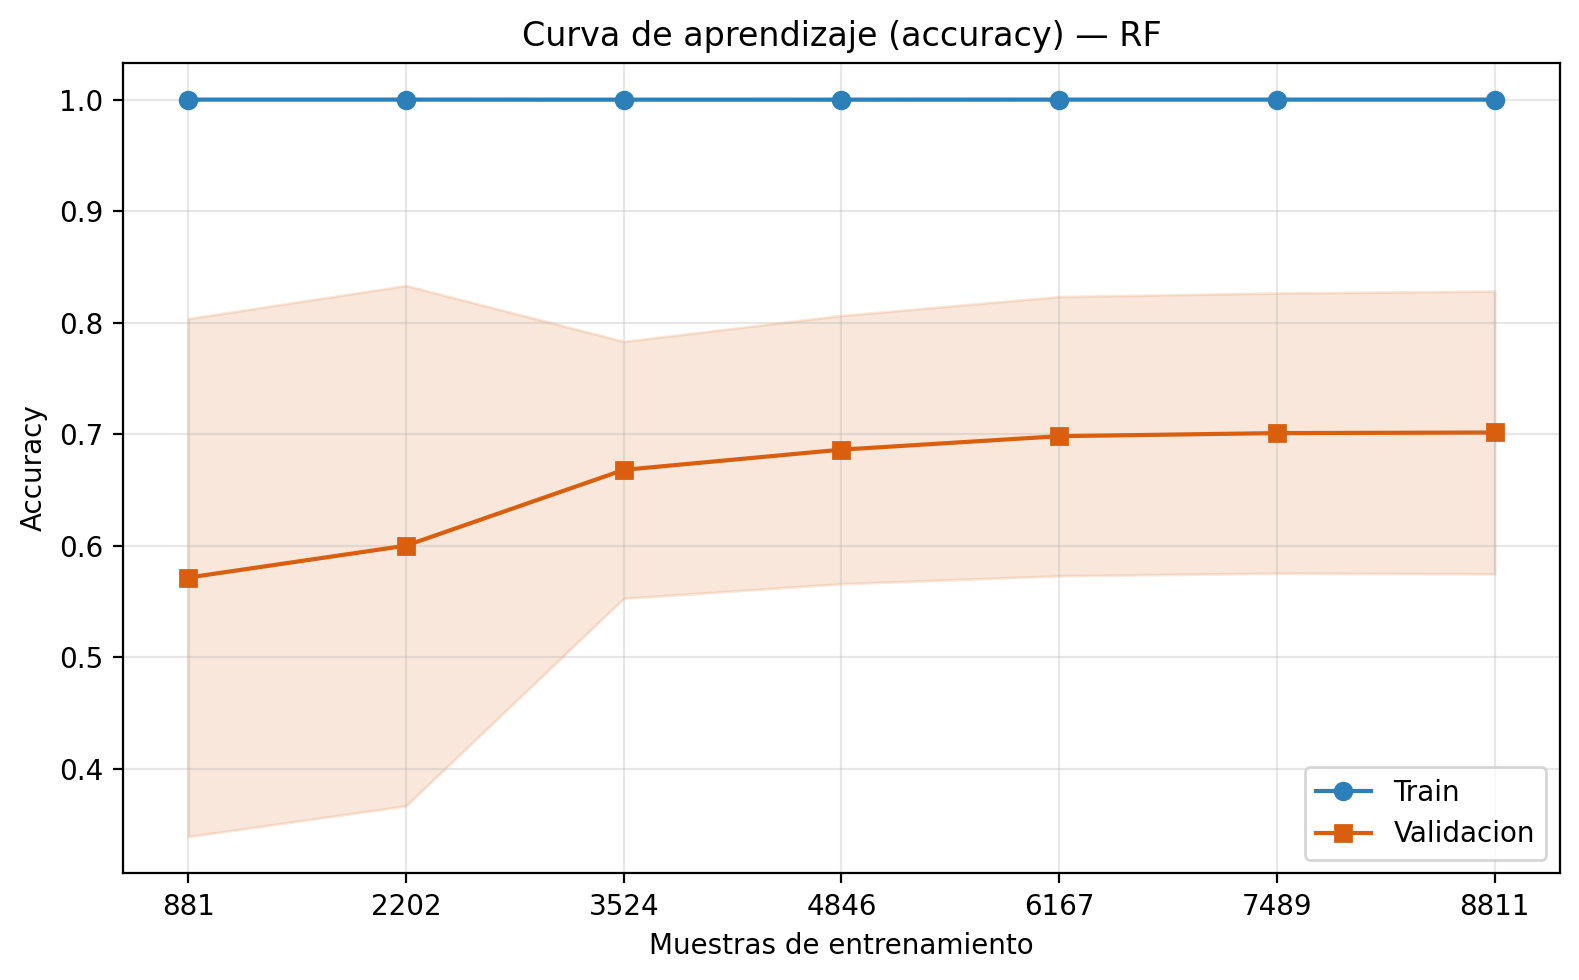

2026-05-29 20:58:07 [info     ] xgb_device_resolved            device=cuda gpu='NVIDIA L4'
2026-05-29 20:58:08 [info     ] learning_curve_subsampled      max_samples=12000 n_kept=12001 n_original=85951
2026-05-29 20:58:08 [info     ] learning_curve_start           n_features=185 n_folds=5 n_samples=12001 n_train_sizes=7 scoring=accuracy
2026-05-29 20:59:27 [info     ] learning_curve_done            train_acc_max=1.0 val_acc_max=0.7174


/home/artzizumbo_gmail_com/.cache/pypoetry/virtualenvs/agrosatcopilot-s31b4B1H-py3.12/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
9 fits failed out of a total of 35.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "/home/artzizumbo_gmail_com/.cache/pypoetry/virtualenvs/agrosatcopilot-s31b4B1H-py3.12/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/artzizumbo_gmail_com/.cache/pypoetry/virtualenvs/agrosatcopilot-s31b4B1H-py3.12/lib/python3.12/site-packages/xgboost/core.py", line 751, in inner_f
    re

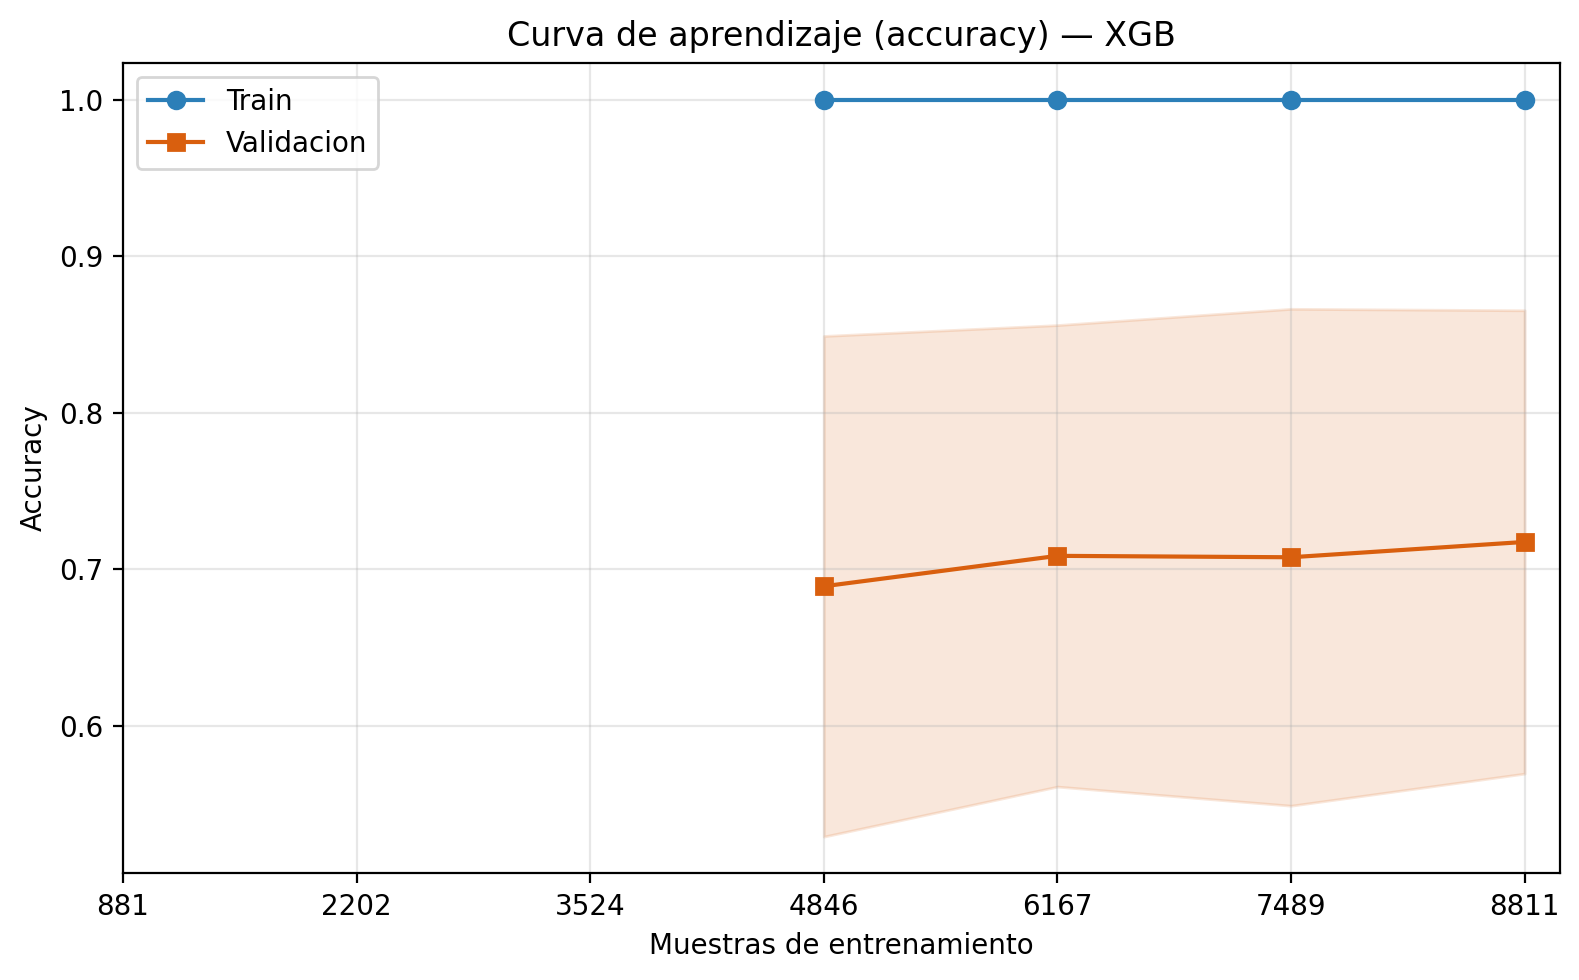

2026-05-29 20:59:27 [info     ] fit_diagnosed                  gap=0.2985 train_acc_max=1.0 val_acc_max=0.7015 verdict=overfit


**Diagnóstico `rf`**: `overfit` (gap = `0.298`, val_acc = `0.702`).

Sobreajuste: el gap train-val es 0.298 (> 0.10). El modelo memoriza el train (accuracy 1.000) pero generaliza peor en validacion (accuracy 0.702).

2026-05-29 20:59:27 [info     ] fit_diagnosed                  gap=0.2826 train_acc_max=1.0 val_acc_max=0.7174 verdict=overfit


**Diagnóstico `xgb`**: `overfit` (gap = `0.283`, val_acc = `0.717`).

Sobreajuste: el gap train-val es 0.283 (> 0.10). El modelo memoriza el train (accuracy 1.000) pero generaliza peor en validacion (accuracy 0.717).

In [16]:
learning_results = {}
for kind in ('rf', 'xgb'):
    estimator = build_estimator(kind, {})
    lc_result, lc_fig = plot_learning_curve(
        estimator,
        df,
        cv_splits=cv_splits,
        max_samples=LEARNING_CURVE_MAX_SAMPLES,
        random_state=RANDOM_STATE,
    )
    learning_results[kind] = lc_result
    # Sobrescribimos el title del axes (ml.eval.learning_curves ya pone
    # 'Curva de aprendizaje (accuracy)'); evitamos un suptitle adicional
    # que se solapaba con el title interno.
    for _ax in lc_fig.axes:
        _ax.set_title(f'Curva de aprendizaje (accuracy) — {kind.upper()}')
    lc_fig.tight_layout()
    lc_fig.savefig(env.figures_dir / f'learning_curve_{kind}.png', bbox_inches='tight')
    display(lc_fig)
    plt.close(lc_fig)

# Diagnostico explicito por modelo.
for kind, lc in learning_results.items():
    diag = diagnose_fit(lc)
    display(Markdown(
        f'**Diagnóstico `{kind}`**: `{diag.verdict}` '
        f'(gap = `{diag.gap:.3f}`, val_acc = `{diag.val_acc_max:.3f}`).\n\n'
        f'{diag.explanation}'
    ))


2026-05-29 21:09:22 [info     ] learning_curve_subsampled      max_samples=12000 n_kept=12001 n_original=85951
2026-05-29 21:09:22 [info     ] learning_curve_start           n_features=185 n_folds=5 n_samples=12001 n_train_sizes=7 scoring=f1_macro
2026-05-29 21:13:49 [info     ] learning_curve_done            train_acc_max=1.0 val_acc_max=0.2292


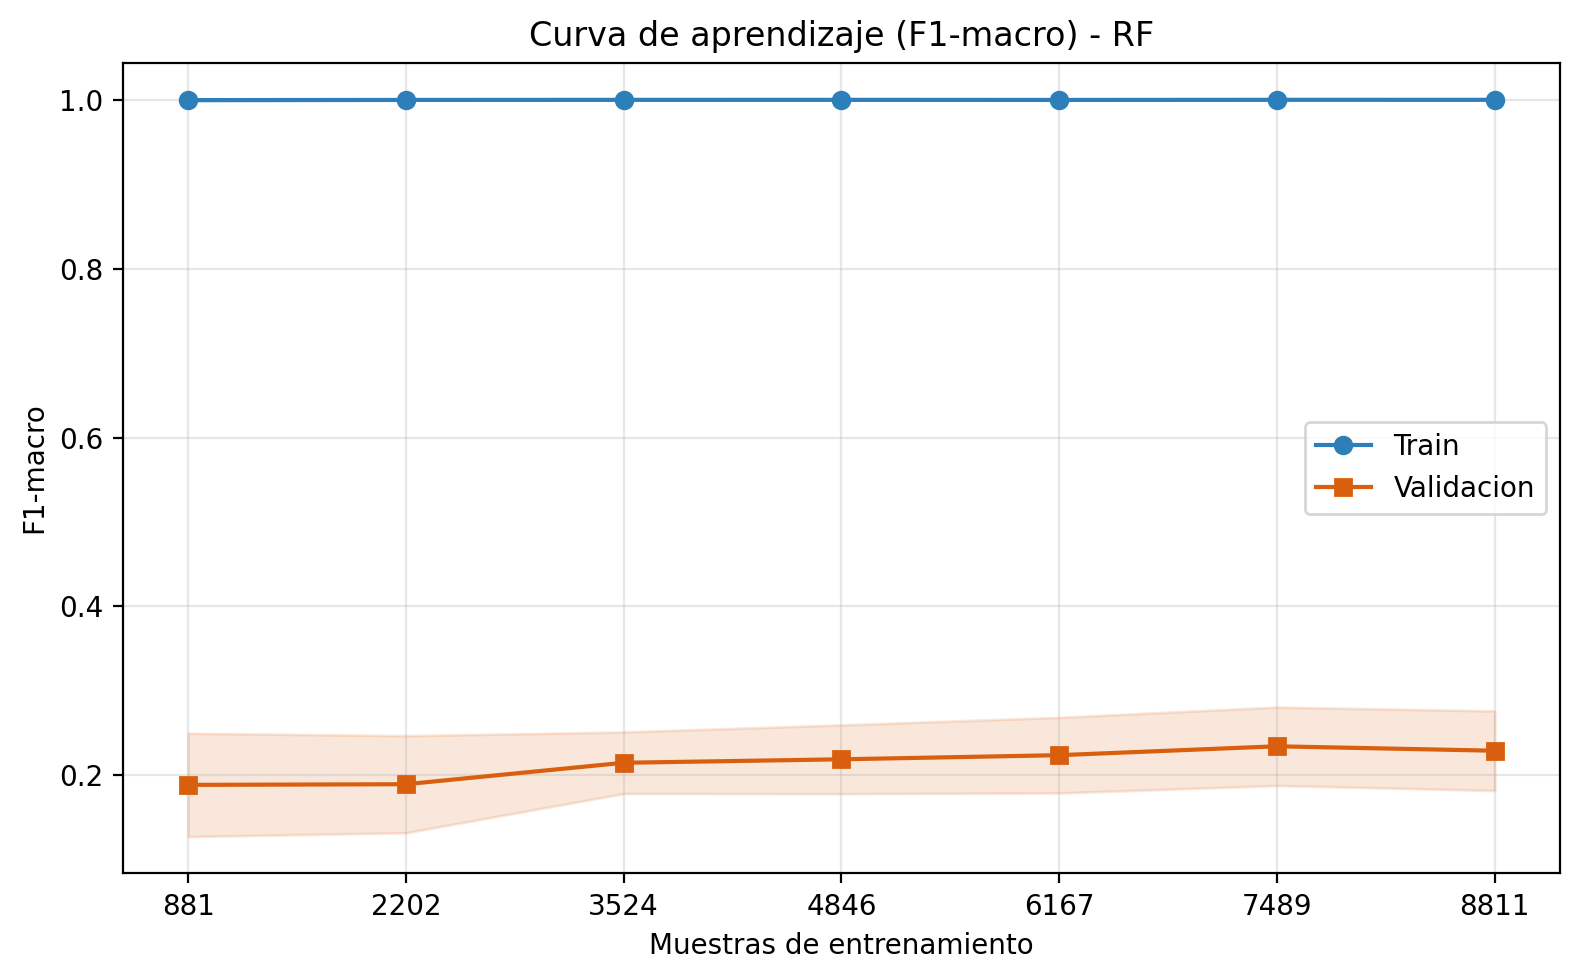

2026-05-29 21:13:50 [info     ] xgb_device_resolved            device=cuda gpu='NVIDIA L4'
2026-05-29 21:13:50 [info     ] learning_curve_subsampled      max_samples=12000 n_kept=12001 n_original=85951
2026-05-29 21:13:50 [info     ] learning_curve_start           n_features=185 n_folds=5 n_samples=12001 n_train_sizes=7 scoring=f1_macro
2026-05-29 21:15:09 [info     ] learning_curve_done            train_acc_max=1.0 val_acc_max=0.2904


/home/artzizumbo_gmail_com/.cache/pypoetry/virtualenvs/agrosatcopilot-s31b4B1H-py3.12/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
9 fits failed out of a total of 35.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "/home/artzizumbo_gmail_com/.cache/pypoetry/virtualenvs/agrosatcopilot-s31b4B1H-py3.12/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/artzizumbo_gmail_com/.cache/pypoetry/virtualenvs/agrosatcopilot-s31b4B1H-py3.12/lib/python3.12/site-packages/xgboost/core.py", line 751, in inner_f
    re

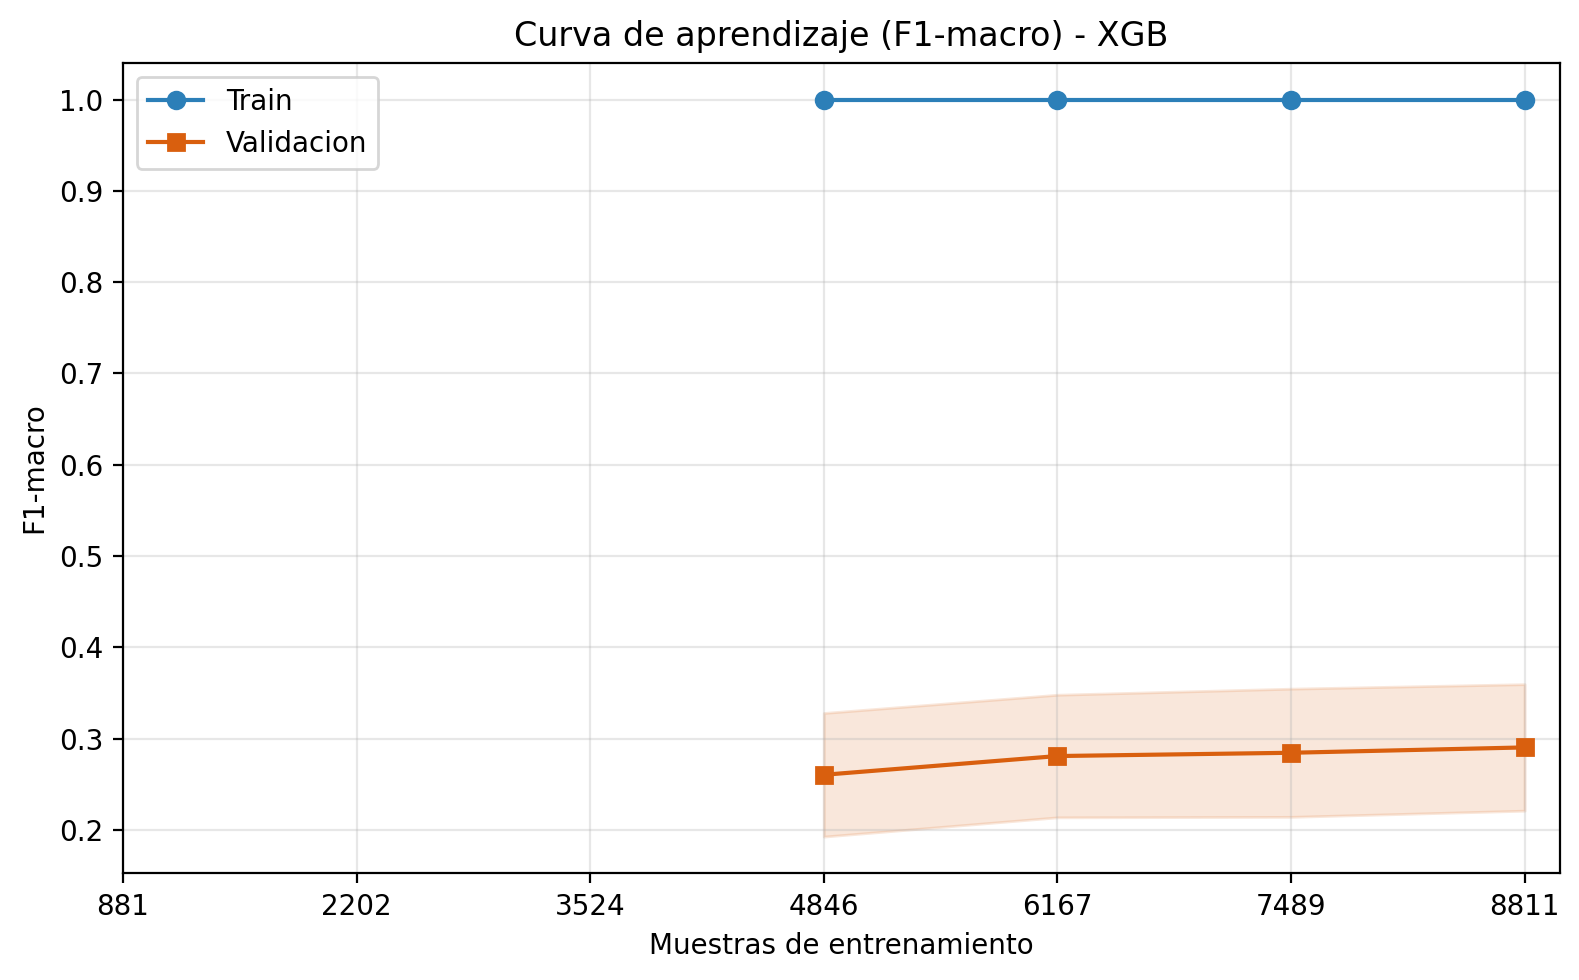

Las curvas en **F1-macro** quedan por debajo de las de accuracy porque F1-macro promedia el desempeno por clase sin ponderar por frecuencia: las clases minoritarias (cultivos poco representados) pesan igual que las mayoritarias y arrastran la metrica. La brecha entre ambas curvas es la firma del desbalance que motiva la agrupacion por familias HCAT mas adelante.

In [17]:
# Learning curve en F1-macro (metrica de decision del proyecto) para
# complementar la de accuracy. F1-macro penaliza el desbalance de clases:
# por eso queda muy por debajo de la accuracy, evidenciando que el reto
# del baseline son las clases minoritarias (resuelto al agrupar en HCAT).
learning_results_f1 = {}
for kind in ('rf', 'xgb'):
    estimator = build_estimator(kind, {})
    lc_result, lc_fig = plot_learning_curve(
        estimator,
        df,
        cv_splits=cv_splits,
        scoring='f1_macro',
        max_samples=LEARNING_CURVE_MAX_SAMPLES,
        random_state=RANDOM_STATE,
    )
    learning_results_f1[kind] = lc_result
    for _ax in lc_fig.axes:
        _ax.set_title(f'Curva de aprendizaje (F1-macro) - {kind.upper()}')
        _ax.set_ylabel('F1-macro')
    lc_fig.tight_layout()
    lc_fig.savefig(env.figures_dir / f'learning_curve_f1_{kind}.png', bbox_inches='tight')
    display(lc_fig)
    plt.close(lc_fig)

display(Markdown(
    'Las curvas en **F1-macro** quedan por debajo de las de accuracy porque '
    'F1-macro promedia el desempeño por clase sin ponderar por frecuencia: '
    'las clases minoritarias (cultivos poco representados) pesan igual que las '
    'mayoritarias y arrastran la métrica. La brecha entre ambas curvas es la '
    'firma del desbalance que motiva la agrupación por familias HCAT mas adelante.'
))


### 6.2 Curvas de validación — `max_depth` (RF) y `n_estimators` (XGB)

2026-05-29 21:16:21 [info     ] learning_curve_subsampled      max_samples=12000 n_kept=12001 n_original=85951
2026-05-29 21:16:21 [info     ] validation_curve_start         n_folds=5 n_samples=12001 n_values=6 param_name=max_depth scoring=accuracy
2026-05-29 21:22:50 [info     ] validation_curve_done          best_val_acc=0.7064 param_name=max_depth


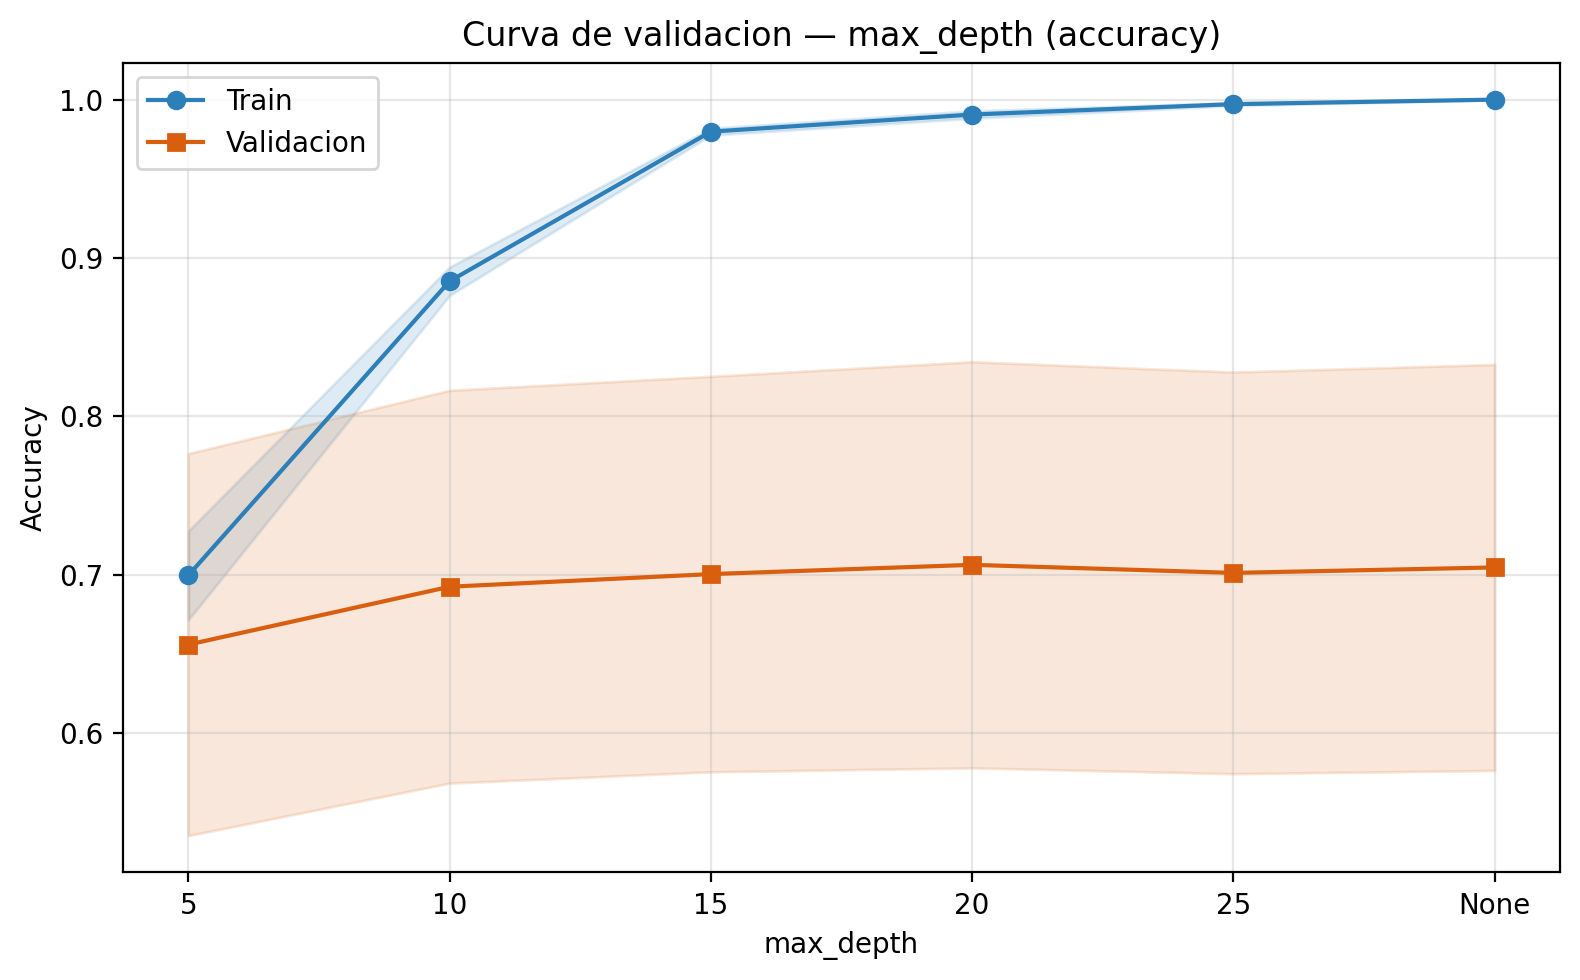

2026-05-29 21:22:50 [info     ] xgb_device_resolved            device=cuda gpu='NVIDIA L4'
2026-05-29 21:22:51 [info     ] learning_curve_subsampled      max_samples=12000 n_kept=12001 n_original=85951
2026-05-29 21:22:51 [info     ] validation_curve_start         n_folds=5 n_samples=12001 n_values=5 param_name=n_estimators scoring=accuracy
2026-05-29 21:25:49 [info     ] validation_curve_done          best_val_acc=0.7181 param_name=n_estimators


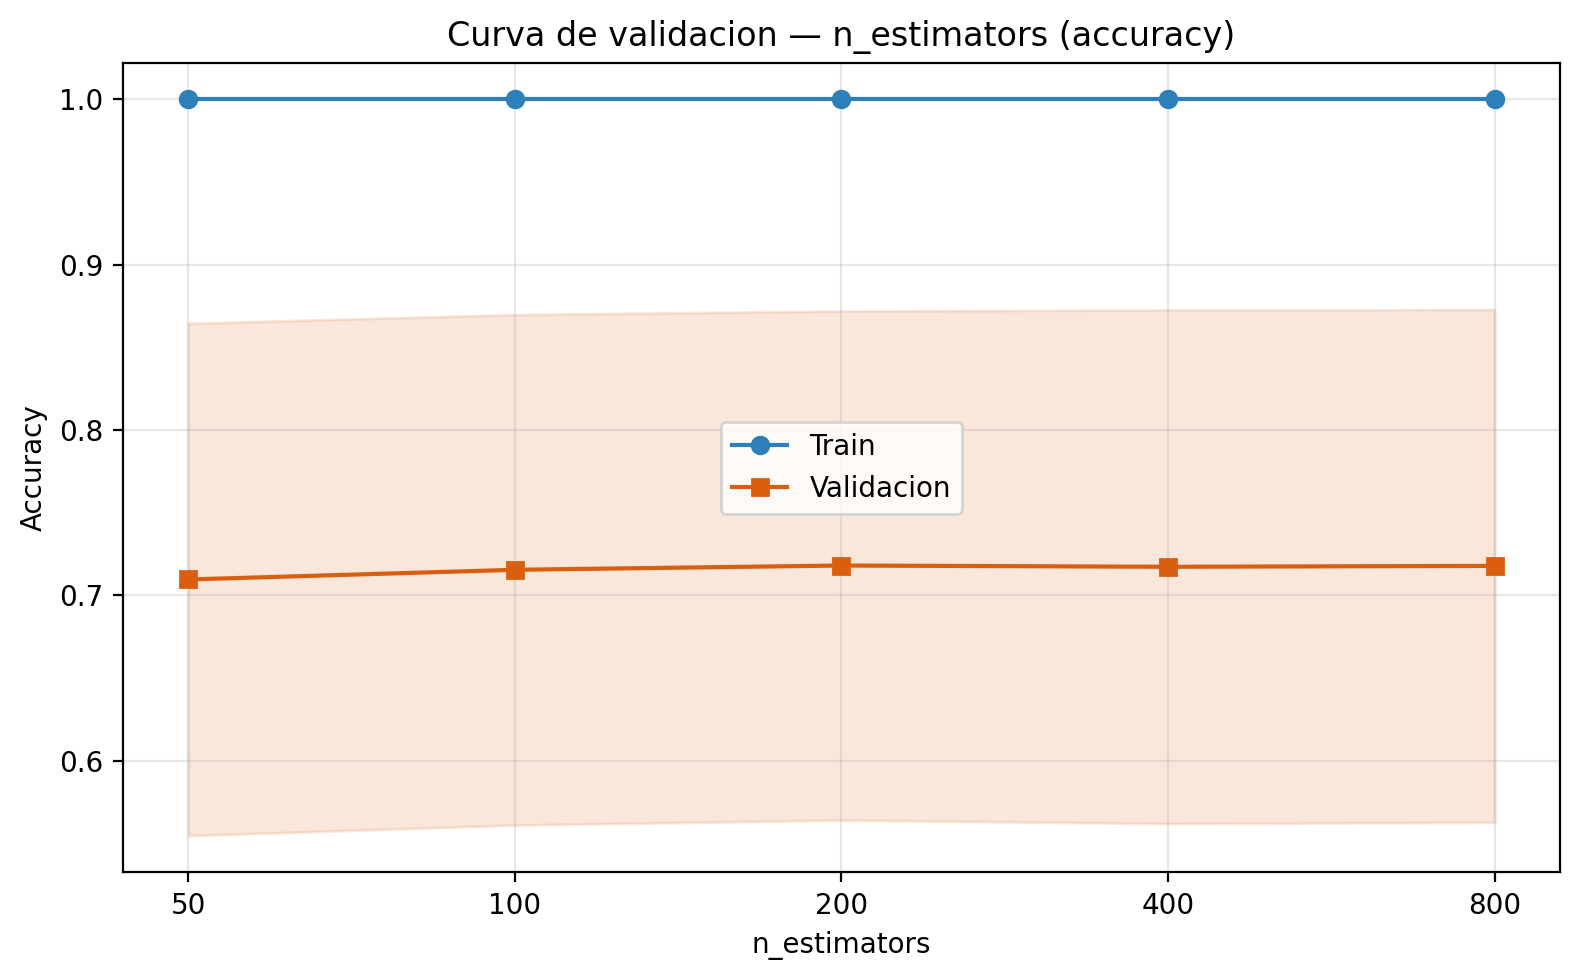

In [ ]:
# Curva de validacion RF - max_depth.
vc_rf_result, vc_rf_fig = plot_validation_curve(
    build_estimator('rf', {}),
    df,
    param_name='max_depth',
    param_range=[5, 10, 15, 20, 25, None],
    cv_splits=cv_splits,
    max_samples=LEARNING_CURVE_MAX_SAMPLES,
    random_state=RANDOM_STATE,
)
vc_rf_fig.savefig(env.figures_dir / 'validation_curve_rf_max_depth.png', bbox_inches='tight')
display(vc_rf_fig)
plt.close(vc_rf_fig)

# Curva de validacion XGB - n_estimators.
vc_xgb_result, vc_xgb_fig = plot_validation_curve(
    build_estimator('xgb', {}),
    df,
    param_name='n_estimators',
    param_range=[50, 100, 200, 400, 800],
    cv_splits=cv_splits,
    max_samples=LEARNING_CURVE_MAX_SAMPLES,
    random_state=RANDOM_STATE,
)
vc_xgb_fig.savefig(env.figures_dir / 'validation_curve_xgb_n_estimators.png', bbox_inches='tight')
display(vc_xgb_fig)
plt.close(vc_xgb_fig)


2026-05-29 21:32:00 [info     ] xgb_device_resolved            device=cuda gpu='NVIDIA L4'
2026-05-29 21:32:01 [info     ] learning_curve_subsampled      max_samples=12000 n_kept=12001 n_original=85951
2026-05-29 21:32:01 [info     ] validation_curve_start         n_folds=5 n_samples=12001 n_values=8 param_name=max_depth scoring=accuracy
2026-05-29 21:35:44 [info     ] validation_curve_done          best_val_acc=0.7157 param_name=max_depth


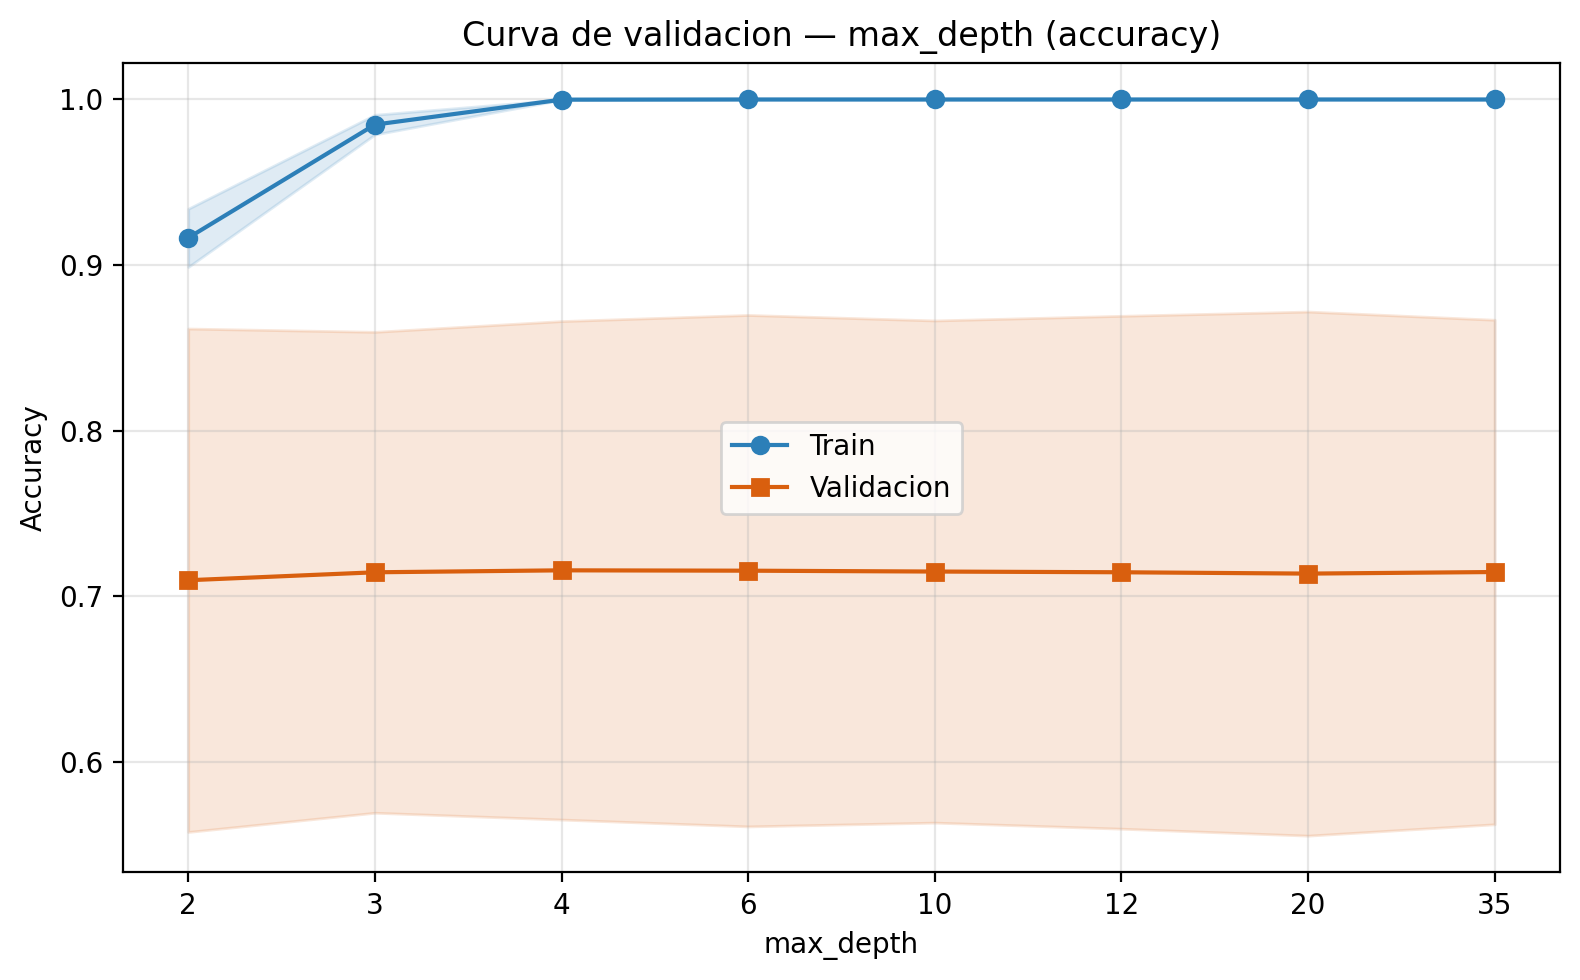

In [19]:
# Curva de validacion XGB - max_depth.
vc_xgb_result2, vc_xgb_fig2 = plot_validation_curve(
    build_estimator('xgb', {}),
    df,
    param_name='max_depth',
    param_range=[2,3,4,6,10,12,20,35],
    cv_splits=cv_splits,
    max_samples=LEARNING_CURVE_MAX_SAMPLES,
    random_state=RANDOM_STATE,
)
vc_xgb_fig2.savefig(env.figures_dir / 'validation_curve_xgb_max_depth.png', bbox_inches='tight')
display(vc_xgb_fig2)
plt.close(vc_xgb_fig2)

**Lectura de las curvas de validación**: el eje X recorre el rango del hiperparámetro y el eje Y muestra accuracy de train y de validación. La zona de equilibrio es donde la curva de validación deja de subir (cualquier valor más alto solo incrementa el gap, no la generalización). Si train sube rápido a 1.0 y val se estanca, el modelo está agotando su capacidad de generalizar sobre estas features.

## 7. Comparativa AlphaEarth vs Sentinel-2 crudo vs vector combinado

Esta sección compara el baseline sobre **tres vistas distintas de las mismas parcelas**, para responder con evidencia una pregunta central: **¿el embedding AlphaEarth aporta valor frente a las bandas Sentinel-2 sin procesar?**

| Escenario | Características | Origen |
|-----------|-----------------|--------|
| **(a) AlphaEarth** | 64 dimensiones | embedding AlphaEarth Foundations v2.1 |
| **(b) Sentinel-2 crudo** | 10 bandas promedio | bandas Sentinel-2 sin procesar, agregadas por parcela |
| **(c) Vector combinado** | 187 características | ingeniería de features espectro-temporales |

Metodología:

- Los 3 escenarios se cruzan por `parcel_id` con un **inner join** para que los tres modelos se evalúen **exactamente sobre el mismo conjunto de parcelas**, no sobre tres muestras distintas.
- Cada escenario entrena RF + XGB con el mismo CV espacial 5-fold y buffer de 1 km.
- La tabla se persiste como CSV, Markdown y LaTeX (`comparison_table.tex`) para reutilizarla en el reporte.

In [20]:
from pathlib import Path
from ml.eval.comparison import (
    build_comparison_table,
    export_comparison_latex,
)

scenario_paths = {
    'alphaearth': SCENARIO_ALPHAEARTH_PATH,
    's2_raw': SCENARIO_S2_RAW_PATH,
    'combined': SCENARIO_COMBINED_PATH,
}
missing = {k: p for k, p in scenario_paths.items() if not Path(p).exists()}
comparison_available = not missing

if missing:
    lines = [f'- `{k}`: `{p}`' for k, p in missing.items()]
    display(Markdown(
        '> **Comparativa omitida**: faltan los siguientes escenarios:\n\n' +
        '\n'.join(lines) +
        '\n\nGenera el escenario S2 crudo con `make s2-raw-parcels` o '
        'descarga AlphaEarth via `dvc pull`.'
    ))
else:
    display(Markdown('Los 3 escenarios están disponibles para la comparativa.'))


Los 3 escenarios están disponibles para la comparativa.

In [21]:
comparison_result = None
if comparison_available:
    comparison_result = build_comparison_table(
        scenario_paths,
        k_folds=COMPARISON_K_FOLDS,
        buffer_km=BUFFER_KM,
        max_samples=COMPARISON_MAX_SAMPLES,
        random_state=RANDOM_STATE,
    )
    display(Markdown(
        f'**Parcelas en el inner join**: `{comparison_result.n_parcels:,}`. '
        f'**Escenario ganador**: `{comparison_result.best_scenario}`. '
        f'**Delta AlphaEarth vs S2 crudo**: `{comparison_result.alphaearth_delta:+.4f}`.'
    ))
    display(comparison_result.table)
    # Persistencia (CSV + MD + LaTeX).
    reports_dir = env.reports_dir
    csv_path = reports_dir / 'comparison_alphaearth_vs_s2.csv'
    comparison_result.table.write_csv(csv_path)
    md_table = (
        '# Comparativa de escenarios - baseline de cultivos\n\n'
        + comparison_result.table.to_pandas().to_markdown(index=False)
        + '\n'
    )
    (reports_dir / 'comparison_alphaearth_vs_s2.md').write_text(
        md_table, encoding='utf-8'
    )
    tex_path = export_comparison_latex(
        comparison_result, reports_dir / 'comparison_table.tex'
    )
    display(Markdown(
        f'Tabla comparativa exportada: '
        f'`{csv_path.relative_to(env.repo)}`, MD y `{tex_path.name}`.'
    ))
else:
    display(Markdown('> Comparativa omitida - ver celda anterior.'))


2026-05-29 21:37:42 [info     ] scenarios_aligned              n_common=85951 scenarios=['alphaearth', 'combined', 's2_raw']
2026-05-29 21:37:42 [info     ] comparison_table_start         k_folds=5 n_effective=85951 n_parcels=85951
2026-05-29 21:37:42 [info     ] spatial_folds_cache_hit        n_folds=5 path=data/test_fixtures/baseline_spatial_folds_n85951_k5_b1_s42.parquet
2026-05-29 21:37:42 [info     ] spatial_cv_start               n_classes=18 n_folds=5
2026-05-29 21:37:42 [info     ] spatial_cv_fold_start          fold=1/5 n_test=23157 n_train=62794
2026-05-29 21:37:42 [info     ] scaler_persisted               n_features=64 n_train=62794 path=/tmp/tmplnwccc5r/fold_0_scaler.joblib version=v1
2026-05-29 21:38:01 [info     ] spatial_cv_fold_done           f1_macro=0.2899 fold=1/5
2026-05-29 21:38:01 [info     ] spatial_cv_fold_start          fold=2/5 n_test=8470 n_train=77481
2026-05-29 21:38:02 [info     ] scaler_persisted               n_features=64 n_train=77481 path=/tmp/tmpt7m

/home/artzizumbo_gmail_com/.cache/pypoetry/virtualenvs/agrosatcopilot-s31b4B1H-py3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


2026-05-29 21:43:41 [info     ] spatial_cv_fold_done           f1_macro=0.3346 fold=1/5
2026-05-29 21:43:41 [info     ] spatial_cv_fold_start          fold=2/5 n_test=8470 n_train=77481
2026-05-29 21:43:42 [info     ] scaler_persisted               n_features=64 n_train=77481 path=/tmp/tmpb68jvql3/fold_1_scaler.joblib version=v1


/home/artzizumbo_gmail_com/.cache/pypoetry/virtualenvs/agrosatcopilot-s31b4B1H-py3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


2026-05-29 21:44:46 [info     ] spatial_cv_fold_done           f1_macro=0.2985 fold=2/5
2026-05-29 21:44:46 [info     ] spatial_cv_fold_start          fold=3/5 n_test=22838 n_train=63113
2026-05-29 21:44:46 [info     ] scaler_persisted               n_features=64 n_train=63113 path=/tmp/tmpi2liq21p/fold_2_scaler.joblib version=v1


...

2026-05-29 22:14:54 [info     ] spatial_cv_fold_done           f1_macro=0.3014 fold=5/5
2026-05-29 22:17:41 [info     ] baseline_trained               f1_macro_oof=0.3901157440984177 model=lgbm n_classes=18 n_features=185 n_samples=85951
2026-05-29 22:17:41 [info     ] comparison_cell_done           f1_macro=0.3901 model=lgbm scenario=combined train_time_s=925.48
2026-05-29 22:17:41 [info     ] comparison_table_done          alphaearth_delta=0.0977 best_scenario='Vector combinado (187 feat)' n_parcels=85951


**Parcelas en el inner join**: `85,951`. **Escenario ganador**: `Vector combinado (187 feat)`. **Delta AlphaEarth vs S2 crudo**: `+0.0977`.

scenario,model,n_features,f1_macro,f1_weighted,miou,train_time_s
str,str,i64,f64,f64,f64,f64
"""Vector combinado (187 feat)""","""XGB""",185,0.4098,0.692,0.3121,308.219
"""Vector combinado (187 feat)""","""LGBM""",185,0.3901,0.6834,0.299,925.48
"""Vector combinado (187 feat)""","""RF""",185,0.3646,0.6571,0.2695,209.683
"""AlphaEarth 64-dim""","""XGB""",64,0.3547,0.6545,0.2595,163.118
"""AlphaEarth 64-dim""","""LGBM""",64,0.3391,0.6443,0.2506,378.717
"""AlphaEarth 64-dim""","""RF""",64,0.3221,0.6306,0.2316,135.916
"""Sentinel-2 crudo (10 bandas)""","""XGB""",10,0.257,0.5634,0.1765,94.531
"""Sentinel-2 crudo (10 bandas)""","""LGBM""",10,0.2561,0.5668,0.1776,131.303
"""Sentinel-2 crudo (10 bandas)""","""RF""",10,0.2044,0.4948,0.135,52.046


2026-05-29 22:17:41 [info     ] comparison_latex_written       path=/mnt/data/agro_sat_copilot/reports/baseline/04_baseline/comparison_table.tex


Tabla comparativa exportada: `reports/baseline/04_baseline/comparison_alphaearth_vs_s2.csv`, MD y `comparison_table.tex`.

### 7.1 Barplot comparativo F1-macro por escenario y modelo

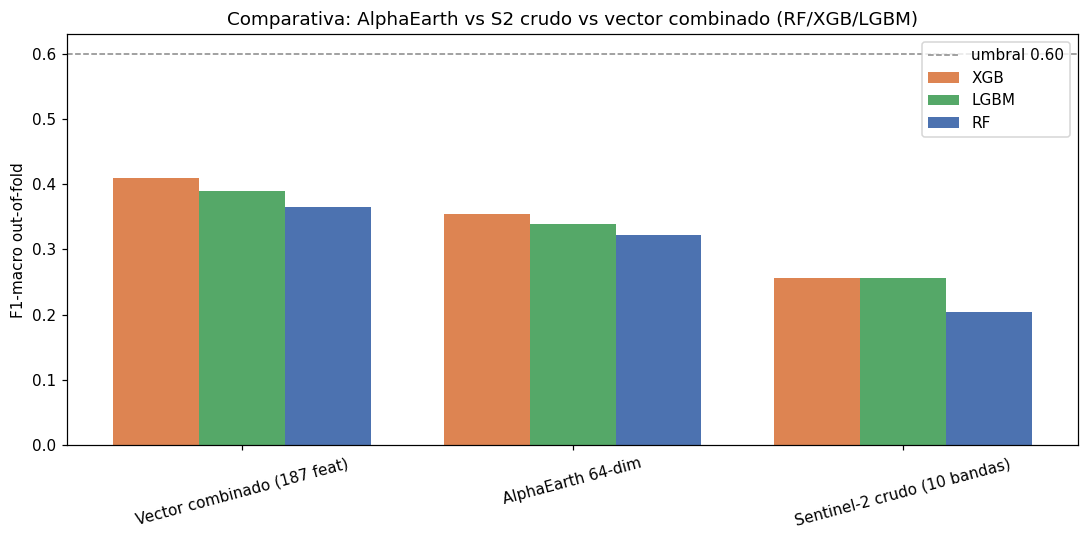

In [22]:
if comparison_result is not None:
    table = comparison_result.table
    scenarios = table['scenario'].unique(maintain_order=True).to_list()
    models = table['model'].unique(maintain_order=True).to_list()
    x = list(range(len(scenarios)))
    width = 0.26  # 3 barras por escenario
    fig, ax = plt.subplots(figsize=(10, 5), dpi=110)
    palette = {'RF': '#4C72B0', 'XGB': '#DD8452', 'LGBM': '#55A868'}
    for i, m in enumerate(models):
        vals = [
            float(table.filter((pl.col('scenario') == s) & (pl.col('model') == m))['f1_macro'][0])
            for s in scenarios
        ]
        offset = (i - (len(models) - 1) / 2) * width
        ax.bar([xi + offset for xi in x], vals, width=width, label=m, color=palette.get(m, '#999'))
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios, rotation=15)
    ax.set_ylabel('F1-macro out-of-fold')
    ax.set_title('Comparativa: AlphaEarth vs S2 crudo vs vector combinado (RF/XGB/LGBM)')
    ax.axhline(F1_THRESHOLD, color='#888', linestyle='--', linewidth=1,
               label=f'umbral {F1_THRESHOLD:.2f}')
    ax.legend(loc='best')
    fig.tight_layout()
    fig.savefig(env.figures_dir / 'comparison_barplot.png', bbox_inches='tight')
    display(fig)
    plt.close(fig)
else:
    display(Markdown('> Barplot omitido - ver seccion 7.'))


**Lectura del barplot**: las barras están agrupadas por escenario, con tres barras (RF, XGB, LGBM) cada una. El delta entre el escenario AlphaEarth y el Sentinel-2 crudo cuantifica el valor incremental del embedding fundacional. Si AlphaEarth supera al S2 crudo con margen claro, ese resumen aprendido vale más que el promedio simple de bandas. Si el vector combinado supera a AlphaEarth, las features espectro-temporales agregan información que el embedding no captura. Comparar LGBM con XGB en cada escenario revela si la elección del algoritmo de boosting altera la conclusión sobre el extractor.

## 8. Dos formas de medir el mismo modelo: 18 clases vs 6 grupos

El F1-macro de las secciones anteriores se calcula sobre las **18 clases planas** de PASTIS-R, y arrastra un problema estructural: varias de esas clases son **hermanas casi indistinguibles** a nivel de parcela. El trigo blando de invierno, el trigo duro de invierno, la cebada de invierno, la cebada de primavera, el triticale y el centeno mixto comparten calendario y firma espectral; separarlos con una sola imagen-resumen anual es casi imposible. Cuando el modelo confunde un trigo con otro trigo, el F1-macro lo penaliza igual que si confundiera un viñedo con una remolacha, aunque para casi cualquier uso agronómico ambos trigos pertenecen al mismo grupo.

La solución estándar en la literatura (Russwürm & Körner 2018; H2Crop 2025) es reportar también la métrica sobre una **taxonomía jerárquica**. Aquí usamos los **6 grupos HCAT Level-1** (Hierarchical Crop and Agriculture Taxonomy v3), que colapsan las 18 clases en seis familias agronómicas: cereales, oleaginosas, tubérculos, leguminosas, leñosos permanentes y otros (pradera + horticultura). Las clases hermanas caen dentro del mismo grupo, de modo que la confusión trigo-con-trigo deja de contar como error.

**El experimento es apples-to-apples**: exactamente las mismas features, la misma validación cruzada espacial (5-fold, buffer 1 km) y el mismo modelo XGBoost. Lo único que cambia es la etiqueta objetivo. Por eso el salto de F1-macro que veremos no viene de un modelo mejor, sino de medir lo que el modelo realmente resuelve.

In [24]:
from ml.utils.baseline_notebook_helpers import (
    load_base_plus_alphaearth_2018_2019,
)
from ml.analysis.hcat_grouping import (
    HCAT_L1_GROUPS,
    HCAT_L1_GROUP_CODES,
    evaluate_flat_vs_grouped,
)
from ml.eval.reencuadre_plots import (
    plot_model_comparison_bars,
    plot_per_class_f1,
)

# Escenario ganador de la ablacion: base (185 features) + AlphaEarth
# 2018 (ae18_NN) + AlphaEarth 2019 (ae19_NN) = 313 columnas, unidas
# por parcel_id (join 1:1, 0 nulls) sobre las 85951 parcelas.
df_hcat = load_base_plus_alphaearth_2018_2019(
    features_path=FEATURES_PATH,
    parcels_geoparquet=PARCELS_GEOPARQUET,
)
n_ae18 = sum(1 for c in df_hcat.columns if c.startswith('ae18_'))
n_ae19 = sum(1 for c in df_hcat.columns if c.startswith('ae19_'))
display(Markdown(
    f'**Escenario ganador**: `{df_hcat.height:,}` parcelas, '
    f'185 features base + `{n_ae18}` columnas AlphaEarth 2018 + '
    f'`{n_ae19}` columnas AlphaEarth 2019.'
))


2026-05-29 22:22:59 [info     ] features_meta_overlap_dropped  overlap=['patch_id', 'instance_id', 'fold', 'n_pixels']
2026-05-29 22:22:59 [info     ] features_loaded_with_meta      enriched_shape=(85951, 194) features_shape=(85951, 192)
2026-05-29 22:23:00 [info     ] base_plus_ae18_ae19_loaded     base_shape=(85951, 194) enriched_shape=(85951, 322) n_ae18=64 n_ae19=64 n_null_ae18=0 n_null_ae19=0


**Escenario ganador**: `85,951` parcelas, 185 features base + `64` columnas AlphaEarth 2018 + `64` columnas AlphaEarth 2019.

### 8.1 Composición de los 6 grupos HCAT Level-1

Cada grupo lista las clases PASTIS-R que absorbe y su código de nodo en la taxonomía HCAT v3 (para trazabilidad del agrupamiento). Los cereales concentran ocho clases hermanas — justamente las que se confunden entre sí en el esquema plano.

In [25]:
from ml.ingest.pastis_loader import PASTIS_R_CLASSES

grouping_rows = []
for group, class_ids in HCAT_L1_GROUPS.items():
    grouping_rows.append({
        'grupo_hcat_l1': group,
        'codigo_hcat': HCAT_L1_GROUP_CODES[group],
        'n_clases': len(class_ids),
        'clases_pastis': ', '.join(
            PASTIS_R_CLASSES.get(c, str(c)) for c in class_ids
        ),
    })
grouping_table = pl.DataFrame(grouping_rows).sort('n_clases', descending=True)
display(grouping_table)


grupo_hcat_l1,codigo_hcat,n_clases,clases_pastis
str,str,i64,str
"""CEREALS""","""3301000000""",8,"""Soft winter wheat, Corn, Winter barley, Spring barley, Winte…"
"""LEGUMES""","""3302000000""",2,"""Leguminous fodder, Soybeans"""
"""OILSEEDS""","""3303000000""",2,"""Winter rapeseed, Sunflower"""
"""OTHER""","""3300000000""",2,"""Meadow, Fruits, vegetables, flowers"""
"""PERMANENT_WOODY""","""3306000000""",2,"""Grapevine, Orchard"""
"""ROOT_CROPS""","""3304000000""",2,"""Beet, Potatoes"""


### 8.2 Entrenamiento y métricas en ambos esquemas

Entrenamos XGBoost con validación cruzada espacial dos veces sobre las mismas features: una con las 18 clases planas y otra con los 6 grupos HCAT. El helper devuelve las cinco métricas out-of-fold de cada esquema y las predicciones para los plots por clase/grupo.

In [26]:
hcat_result = evaluate_flat_vs_grouped(
    df_hcat,
    model='xgb',
    k_folds=K_FOLDS,
    buffer_km=BUFFER_KM,
    random_state=RANDOM_STATE,
)
metric_order = ['f1_macro', 'f1_weighted', 'miou', 'accuracy', 'cohen_kappa']
metric_label = {
    'f1_macro': 'F1-macro', 'f1_weighted': 'F1-weighted', 'miou': 'mIoU',
    'accuracy': 'accuracy', 'cohen_kappa': 'Cohen kappa',
}
hcat_metrics_table = pl.DataFrame({
    'metrica': [metric_label[m] for m in metric_order],
    'flat_18_clases': [round(hcat_result.flat_metrics[m], 4) for m in metric_order],
    'grouped_6_hcat': [round(hcat_result.grouped_metrics[m], 4) for m in metric_order],
    'delta': [
        round(hcat_result.grouped_metrics[m] - hcat_result.flat_metrics[m], 4)
        for m in metric_order
    ],
})
hcat_metrics_path = env.reports_dir / 'hcat_flat18_vs_grouped6.parquet'
hcat_metrics_table.write_parquet(hcat_metrics_path)
display(Markdown(
    f'**F1-macro 18 clases** = `{hcat_result.flat_metrics["f1_macro"]:.4f}` · '
    f'**F1-macro 6 grupos HCAT** = `{hcat_result.grouped_metrics["f1_macro"]:.4f}` · '
    f'**delta** = `{hcat_result.delta_f1_macro:+.4f}` '
    f'(sobre `{hcat_result.n_samples:,}` parcelas, `{hcat_result.n_features}` features)'
))
display(hcat_metrics_table)


2026-05-29 22:23:21 [info     ] spatial_folds_cache_hit        n_folds=5 path=data/test_fixtures/baseline_spatial_folds_n85951_k5_b1_s42.parquet
2026-05-29 22:23:21 [info     ] spatial_cv_start               n_classes=18 n_folds=5
2026-05-29 22:23:21 [info     ] spatial_cv_fold_start          fold=1/5 n_test=23157 n_train=62794
2026-05-29 22:23:22 [info     ] scaler_persisted               n_features=313 n_train=62794 path=/tmp/tmp4251t7jh/fold_0_scaler.joblib version=v1
2026-05-29 22:23:23 [info     ] xgb_device_resolved            device=cuda gpu='NVIDIA L4'
2026-05-29 22:24:30 [info     ] spatial_cv_fold_done           f1_macro=0.4419 fold=1/5
2026-05-29 22:24:30 [info     ] spatial_cv_fold_start          fold=2/5 n_test=8470 n_train=77481
2026-05-29 22:24:31 [info     ] scaler_persisted               n_features=313 n_train=77481 path=/tmp/tmpz1z02ft_/fold_1_scaler.joblib version=v1
2026-05-29 22:24:32 [info     ] xgb_device_resolved            device=cuda gpu='NVIDIA L4'
2026-05-29

**F1-macro 18 clases** = `0.4352` · **F1-macro 6 grupos HCAT** = `0.6564` · **delta** = `+0.2212` (sobre `85,951` parcelas, `313` features)

metrica,flat_18_clases,grouped_6_hcat,delta
str,f64,f64,f64
"""F1-macro""",0.4352,0.6564,0.2212
"""F1-weighted""",0.7126,0.8294,0.1167
"""mIoU""",0.3278,0.5336,0.2059
"""accuracy""",0.7508,0.8407,0.0899
"""Cohen kappa""",0.6866,0.7671,0.0805


### 8.3 F1-macro lado a lado

La barra de la izquierda es lo que el modelo logra cuando se le exige separar cada trigo de cada otro trigo; la de la derecha, lo que logra cuando solo se le pide acertar la familia agronómica.

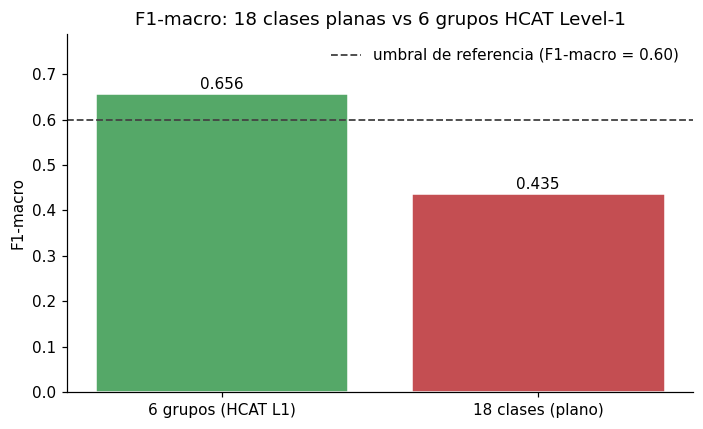

In [27]:
fig_hcat_cmp = plot_model_comparison_bars(
    {
        '18 clases (plano)': hcat_result.flat_metrics['f1_macro'],
        '6 grupos (HCAT L1)': hcat_result.grouped_metrics['f1_macro'],
    },
    baseline_value=F1_THRESHOLD,
    baseline_label=f'umbral de referencia (F1-macro = {F1_THRESHOLD:.2f})',
    title='F1-macro: 18 clases planas vs 6 grupos HCAT Level-1',
)
fig_hcat_cmp.savefig(env.figures_dir / 'hcat_flat18_vs_grouped6.png', bbox_inches='tight')
display(fig_hcat_cmp)
plt.close(fig_hcat_cmp)


### 8.4 F1 por grupo HCAT y diagnóstico por clase plana

El F1 por grupo muestra dónde queda el residuo de error tras agrupar: los grupos con poco soporte siguen siendo difíciles aunque sean homogéneos. La tabla de las clases planas más débiles confirma que el cuello de botella del esquema de 18 es la confusión entre cultivos hermanos, no la falta de señal.

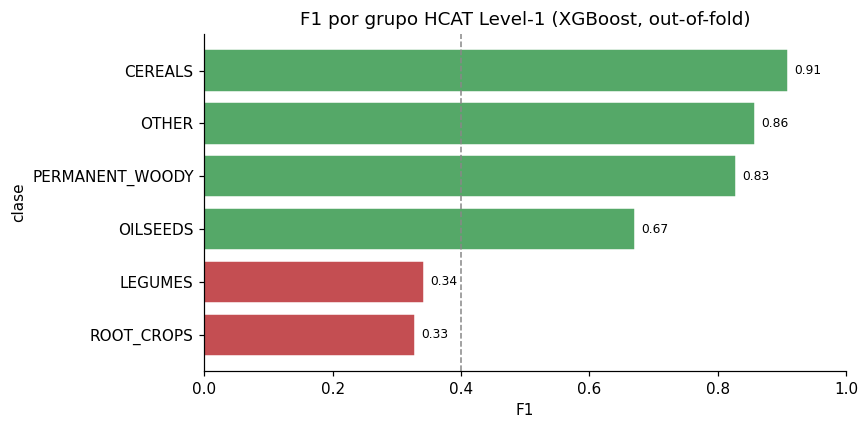

**F1 por grupo HCAT Level-1** (ordenado por id de grupo):

label_id,label_name,f1,support
i64,str,f64,i64
0,"""CEREALS""",0.9095,29470
1,"""LEGUMES""",0.342,4386
2,"""OILSEEDS""",0.6708,3124
3,"""OTHER""",0.8585,33911
4,"""PERMANENT_WOODY""",0.8291,13638
5,"""ROOT_CROPS""",0.3287,1422


**Las 6 clases planas más débiles** (confusión entre hermanas): su F1 cercano a cero es lo que el agrupamiento HCAT recupera.

label_id,label_name,f1,support
i64,str,f64,i64
10,"""Winter durum wheat""",0.0,1704
15,"""Orchard""",0.0193,2998
17,"""Sorghum""",0.0624,707
16,"""Mixed cereal""",0.1854,848
12,"""Potatoes""",0.2151,551
13,"""Leguminous fodder""",0.2855,3174


In [28]:
fig_hcat_f1 = plot_per_class_f1(
    hcat_result.grouped_y_true,
    hcat_result.grouped_y_pred,
    class_labels=list(range(len(hcat_result.grouped_label_names))),
    class_names=hcat_result.grouped_label_names,
    weak_threshold=0.40,
    title='F1 por grupo HCAT Level-1 (XGBoost, out-of-fold)',
)
fig_hcat_f1.savefig(env.figures_dir / 'hcat_per_group_f1.png', bbox_inches='tight')
display(fig_hcat_f1)
plt.close(fig_hcat_f1)

display(Markdown('**F1 por grupo HCAT Level-1** (ordenado por id de grupo):'))
display(hcat_result.grouped_per_group)

weakest_flat = hcat_result.flat_per_class.sort('f1').head(6)
display(Markdown(
    '**Las 6 clases planas más débiles** (confusión entre hermanas): '
    'su F1 cercano a cero es lo que el agrupamiento HCAT recupera.'
))
display(weakest_flat)


### 8.5 Lectura del salto

El aumento del F1-macro al pasar de 18 clases a 6 grupos no es un truco para inflar la cifra: es la medida de **cuánto del error del esquema plano era confusión dentro de la misma familia agronómica**. Si el salto es grande, significa que el modelo ya distingue bien las familias (cereal vs leñoso vs oleaginosa) y que el residuo se concentra en separar cultivos que comparten firma. Ese diagnóstico orienta la fase siguiente: los modelos densos del Avance 4 tendrán que apoyarse en la **dinámica temporal intra-temporada** — no en una imagen-resumen anual — para empezar a separar los trigos entre sí.

## 9. Conclusiones

Este cuaderno construyó un punto de referencia para clasificar cultivos a partir de imágenes satelitales y lo sometió a las cinco preguntas planteadas al inicio. Lo que encontramos:

### ¿Por qué tres modelos de árboles?

Las tres familias (bagging, boosting clásico y boosting histogram-based) acotan el desempeño desde ángulos distintos y permiten descartar que un resultado sea un artefacto de un único algoritmo. La sección 3 muestra cuál de los tres ganó con datos.

### ¿Qué características explican las predicciones?

La importancia nativa (sección 5.1) ordena rápidamente las features; SHAP (sección 5.2) explica **cómo** desplazan la predicción y permite leer interacciones. Las top features dependen del modelo: RF y XGB suelen coincidir en las primeras 5-10 posiciones, con discrepancias en las cola que señalan variables con efectos no lineales que SHAP captura mejor que la importancia simple.

### ¿Cuánto del poder predictivo proviene de AlphaEarth?

La tabla de dominancia (sección 5.3) cuenta cuántas de las 20 features más influyentes son dimensiones `dim_NN`. Si la mayoría son del embedding, AlphaEarth está cargando con el trabajo principal; si los índices espectrales y estadísticas estacionales aparecen mezclados, el feature engineering sigue siendo imprescindible incluso con un buen embedding fundacional.

### ¿Sub o sobreajuste?

Las curvas de aprendizaje (sección 6.1) y `diagnose_fit` entregan un veredicto explícito (`overfit`, `underfit`, `good_fit`) basado en el gap train-val y la accuracy de validación. Las curvas de validación (sección 6.2) muestran el rango útil de `max_depth` (RF) y `n_estimators` (XGB) — más capacidad allí no mejora generalización.

### ¿AlphaEarth aporta valor frente a S2 crudo?

La sección 7 contesta con datos: el delta de F1-macro entre el escenario AlphaEarth y el Sentinel-2 crudo cuantifica cuánto vale el resumen aprendido del embedding. Si la diferencia es positiva y grande, la decisión de usar AlphaEarth como base del baseline queda validada con evidencia, no con un argumento teórico.

### ¿Qué tan bueno es el baseline de verdad?

La sección 8 lo pone en perspectiva. Medido sobre las 18 clases planas, el F1-macro parece modesto, pero buena parte de ese número es el castigo por confundir cultivos hermanos (trigo-con-trigo, cereal-con-cereal) que para el uso agronómico son intercambiables. Al medir el mismo modelo sobre los 6 grupos HCAT Level-1 — sin cambiar features ni validación — el F1-macro sube de forma marcada: la señal para distinguir **familias de cultivo** ya está presente en el embedding anual; lo que falta es resolución intra-familia, que solo aporta la dinámica temporal. El baseline, leído por familias, es más fuerte de lo que sugiere la métrica plana.

## Lo que sigue

- `04c_baseline.ipynb` mide el aporte incremental de cada bloque del vector fused (`alphaearth_only`, `phenology_only`, `no_geom`, `geom_only` como test de leakage).
- `05_reencuadre_fenologico.ipynb` cuantifica el aporte de los bloques opcionales (FarSLIP, descripción fenológica textual con Gemini, firma espectral REP) sobre este conjunto.
- `Avance3.Equipo17.ipynb` selecciona y guarda el conjunto ganador (`select_winning_features`) para los modelos densos del Avance 4.